<a href="https://colab.research.google.com/github/uniquegalaxycoder/Project/blob/main/ReneWind.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ReneWind**

**Business Context**

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S. Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

**Objective**



“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data on generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set, and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators can be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

True positives (TP) are failures correctly predicted by the model. These will result in repair costs.
False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
False positives (FP) are detections where there is no failure. These will result in inspection costs.
It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variable should be considered as “failure” and “0” represents “No failure”.

In [1]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import time
import math

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# to scale the data for training the model
from sklearn.preprocessing import RobustScaler

import tensorflow as tf #An end-to-end open source machine learning platform
from tensorflow import keras  # High-level neural networks API for deep learning.
from keras import backend   # Abstraction layer for neural network backend engines.
from keras.models import Sequential  # Model for building NN sequentially.
from keras.layers import Dense

# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
keras.utils.set_random_seed(812)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

**Loading the dataset**

In [3]:
  # connecting google drive to colab
from google.colab import drive
drive.mount('/content/drive', force_remount= True)

Mounted at /content/drive


Neural Networks ReneWind Train data.csv

In [4]:
# Load data
try :
  data = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/Neural Networks ReneWind Train data.csv') # importing train data set
  data1 = pd.read_csv('/content/drive/My Drive/Python 2026/practice csv files/Neural Networks ReneWind Test data.csv') # importing a test dataset
  print(" 🚀 Data loaded successfuly")
except Exception as a :
  print(a)

 🚀 Data loaded successfuly


In [5]:
# making the copy of original data
df = data.copy()
df2 = data1.copy()

In [6]:
# checking the table shape

rows, columns = df.shape
print(f"Total Rows : {rows} \nTotal Columns : {columns}")

Total Rows : 20000 
Total Columns : 41


In [7]:
# checking the table info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

Exceept Target Veriable, all veriables are in float data type.
There is two columns where null value are present.

In [8]:
# checking the null values
df.isnull().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


V1 & V2 sensores are having null values, there are 18 rows contains messing data.

In [9]:
# checking the duplicate are present or not in table
df.duplicated().sum()

np.int64(0)

No duplicates rows are present in table.

In [10]:
# checking the table values by head & tail
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


In [11]:
df.tail()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,8.868415,1.717155,1.357838,-1.777135,0.709780,4.944939,-3.100454,-1.199228,-1.084629,-0.365044,3.131175,-3.948103,-3.578469,-8.139067,-1.936861,-1.327691,-0.402688,-1.734796,9.996461,6.955367,-3.938493,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,-2.094760,-1.525834,0.071573,-3.540142,-2.762006,-10.632206,-0.495236,1.720074,3.871596,-1.209610,-8.222073,2.120866,-5.491808,1.452340,1.450002,3.684654,1.076760,-0.384175,-0.838593,-0.748275,-1.088553,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,-3.781972,2.180042,6.111780,1.984747,-8.330002,-1.639184,-0.914960,5.672348,-3.924200,2.133196,-4.502031,2.777178,5.727949,1.619818,-1.699691,-0.041882,-2.923094,-2.760158,-2.253766,2.552033,0.981858,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,1.583029,3.571478,9.226573,2.553587,-7.039109,-0.993573,-9.664938,1.155224,3.876895,3.523634,-7.015329,-0.132037,-3.446179,-4.801443,-0.875727,-3.811854,5.422077,-3.732322,0.608811,5.256460,1.914766,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,-9.589075,3.176560,1.054517,-1.415882,-4.668611,-5.405377,3.719759,2.892923,2.328591,1.457704,-6.428543,1.818232,0.805897,7.786026,0.330857,5.257424,-4.867417,-0.818941,-5.667393,-2.860975,4.674280,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


In [12]:
# checking the table stats
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


Higher Std means More variability, V32, V27, V16, V23, V38 sensore showing high std.

In [13]:
# checking the total data against target variable
df['Target'].value_counts()

,count
Target,
0,18890
1,1110


In [14]:
df['Target'].value_counts(normalize= True)

,proportion
Target,
0,0.9445
1,0.0555


The dataset shows a severe imbalance, with 18890 Not failure records (94.45%) and only 1110 failure records (5.55%). This high imbalance will likely require special handling for model training.

### **Exploratory Data Analysis**

In [15]:
# Univariate analysis

def histplot_boxplot(df, features:list):

  """
  Plot Histogram and Boxplot for given features.

    Parameters:
    df : pandas.DataFrame
        Input dataset
    features : list
        List of numerical column names

    Returns:
    None
  """

  n_column = 3
  n_rows = math.ceil(len(features)/n_column)
  # Defining the plot size of histogram
  plt.figure(figsize = (18, 3*n_rows))
  # plotting the histplot using features & data
  for j, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, j + 1)
    sns.histplot(data = df, x = feature, kde = True, color = 'skyblue')

    plt.title(f"Histogram of {feature}")
  plt.tight_layout
  plt.show()

    # ploting boxplot using features list & data
  plt.figure(figsize = (18, 3* n_rows))
  for k, feature in enumerate(features) :
    plt.subplot(n_rows, n_column, k + 1)
    sns.boxplot(data = df, x = feature, color = 'lightgreen')

    plt.title(f"Boxplot of {feature}")

  plt.tight_layout
  plt.show()

In [16]:
def count_plot(data, x):
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Summary table
    summary = (
        data.groupby(x)
        .size()
        .div(len(data))
        .reset_index(name='Percentage')
    )

    # Figure size based on categories
    n = data[x].nunique()
    plt.figure(figsize=(n * 3, 4))

    # Plot
    plot = sns.countplot(data=data, x=x, palette="viridis")

    # Add labels on bars
    for container in plot.containers:
        plot.bar_label(container)

    plt.title(f"{x} Distribution")
    plt.xlabel(x)
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    plt.show()

    return summary

In [17]:
# bi-variate Analysis

def bargraph_plot(data, x, hue):

  summary = data.groupby([x, hue]).size().div(data.shape[0]).reset_index(name = 'Percentage')

  n = data[x].nunique()  # total unique values
  plt.figure(figsize = (n*3.5, 4))   # figure size
  bar_width = min(0.8, max(0.8, 2/n))  # set bar width
  plt.title(f"{x} Vs. {hue}") # title
  plot = sns.countplot(data=data, x = x, hue = hue, palette= "viridis" , width = bar_width)  # plotting graph
  # plt.ylim(0,  data[hue].value_counts().max()) # set bar hight
  for value in plot.containers :   # plotting values on bar
    plot.bar_label(value)
  return summary
  plt.show()

### **Univariate Analysis**

In [18]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


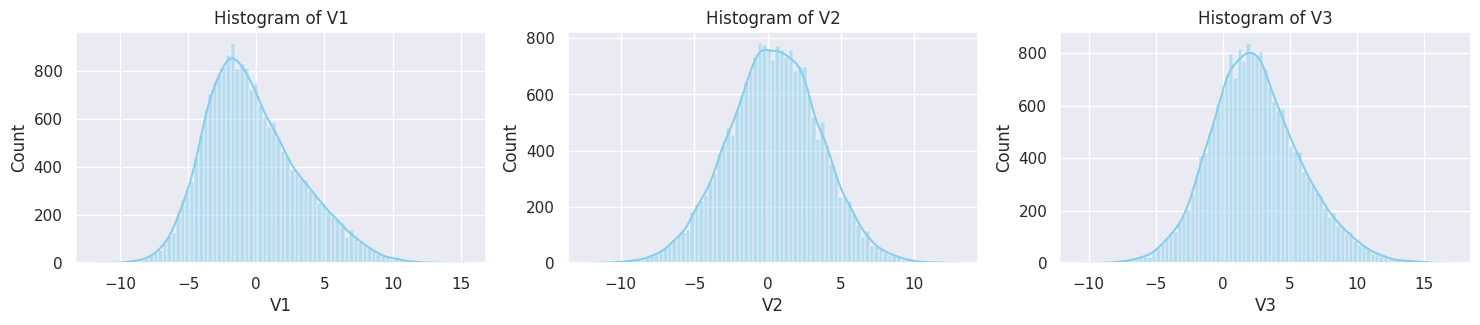

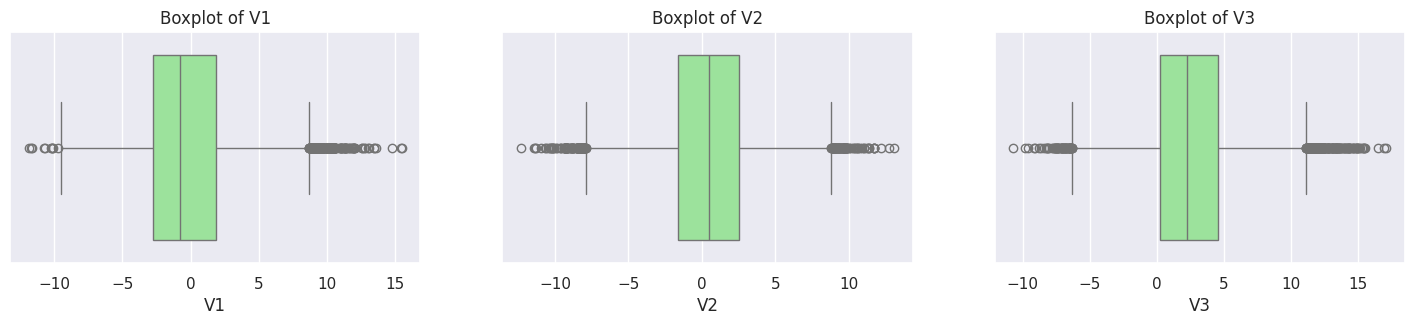

In [19]:
histplot_boxplot(df, ['V1', 'V2', 'V3'])

**V1** :
- distribution is right side skewed not perfectly bell shape.
- Both the side outliers are present but high number of outliers are present in left side.
- Positive outliers above approximately 9 & negative outliers are below approximately -9

**V2** :
- distribution is very slightly left side skewed not perfectly bell shape.
- Both the side outliers are present. Positive outliers above approximately 9 & negative outliers are below approximately -8

**V3** :
- The histogram shows a bell-shaped curve centered around 2-3.
- median is around 2.5, Q1 is 0.2 & Q3 is 4.5 so interquartile range is Q1-Q3 is 4.3 so 50% of observation is lies between the 0.2 & 4.5.
- Lower bound Q1 - 1.5*IQR is -6.25 & Upper Bound is 10.95 So, any value Beyound this two values are outliers.

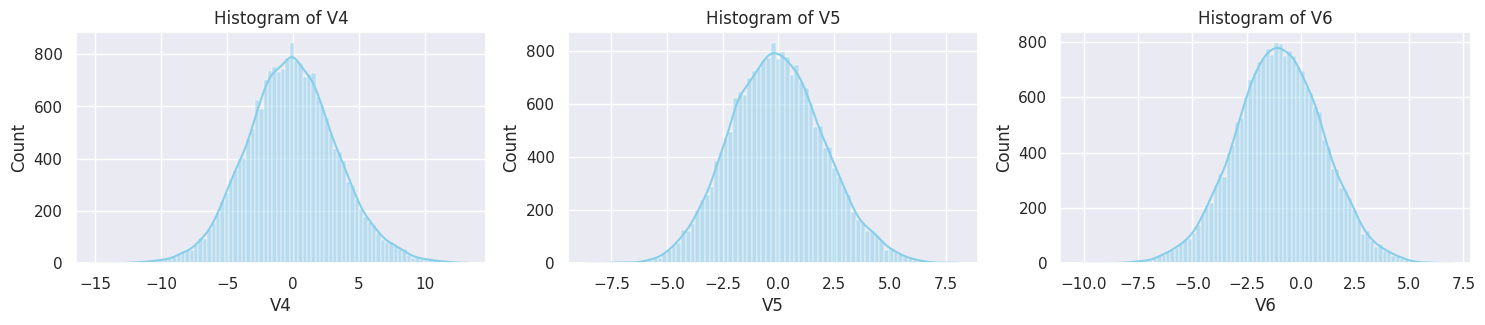

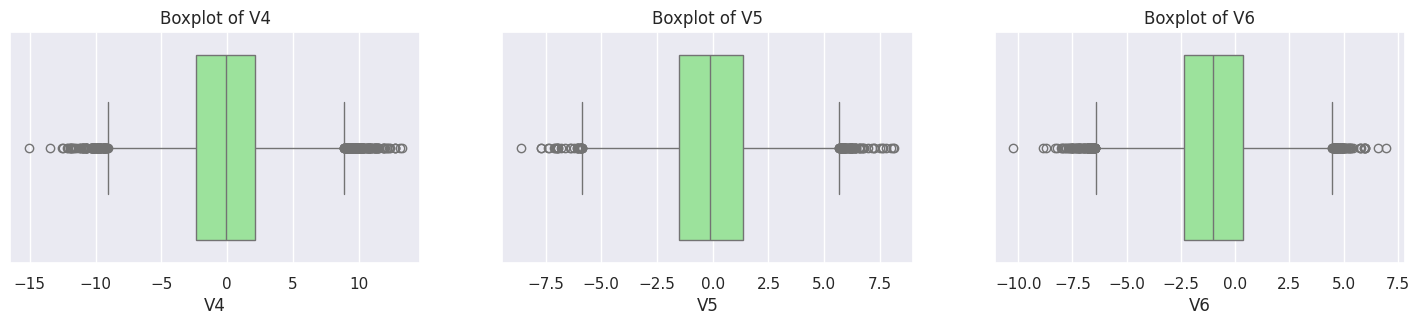

In [20]:
histplot_boxplot(df, ['V4', 'V5', 'V6'])

**V4 :**
- Distribution is approximately normal (bell-shaped) and centered around 0.
- Slightly wider spread compared to V5 and V6.
- Outliers are present on both sides (around -15 and +13).
- Most values lie between -5 and +5.

**V5 :**
- Distribution is close to symmetric and normal.
- Mean and median appear very close to 0.
- Less spread than V4.
- Outliers exist on both sides (around -8 and +8).


**V6 :**
- Distribution is approximately normal but shifted slightly toward the negative side.
- Most observations are concentrated around -1.
- Outliers present on both sides, especially below -9.
- Moderate spread compared to V4 and V5.

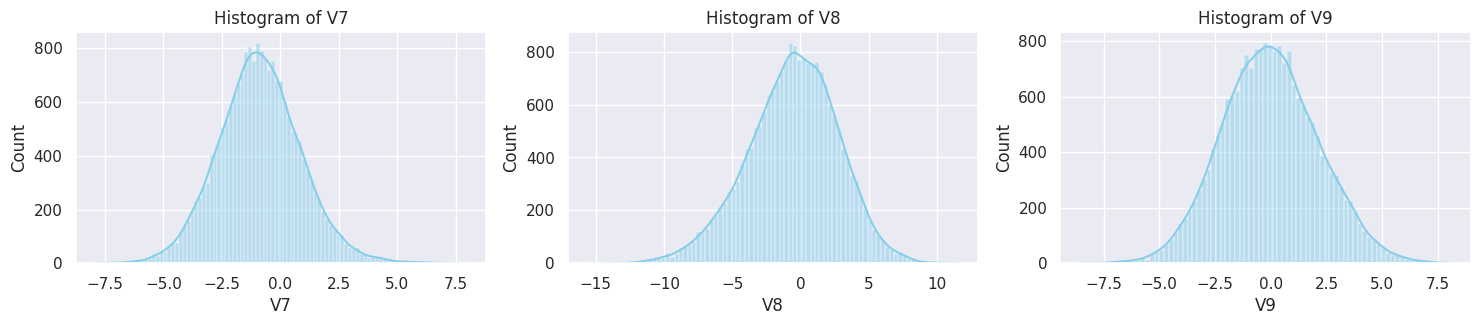

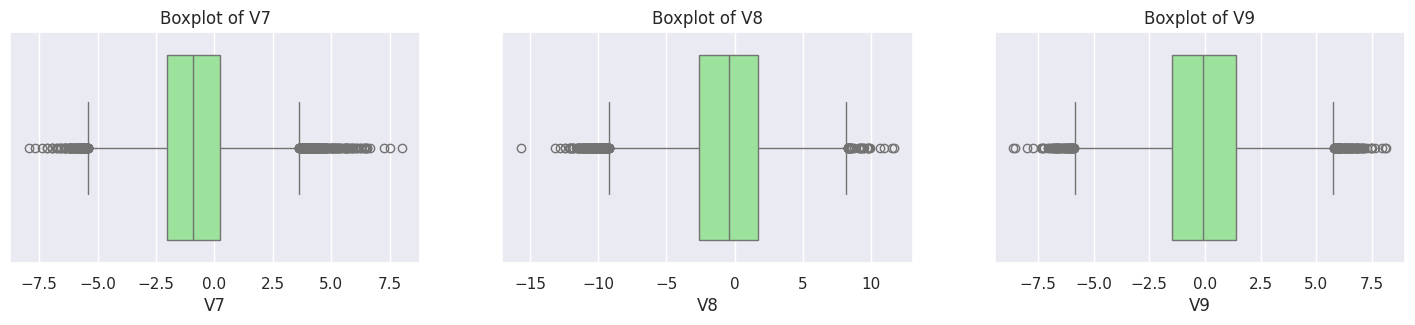

In [21]:
histplot_boxplot(df, ['V7', 'V8', 'V9'])

**V7 :**
- Distribution is approximately normal (bell-shaped) and centered slightly below 0.
- Moderate spread, with most values concentrated between -4 and +3.
- Outliers are present on both sides (around -8 and +8).
- Slight negative shift compared to V8 and V9.

**V8 :**
- Distribution is approximately normal and centered close to 0.
- Widest spread among V7, V8, and V9.
- Most values lie between -6 and +6.
- Contains several extreme outliers on both sides (around -15 and +10).

**V9 :**
- Distribution is close to symmetric and bell-shaped, centered slightly above 0.
- Spread is similar to V7 but narrower than V8.
- Most values fall between -4 and +4.
- Outliers are present on both ends (around -8 and +8).

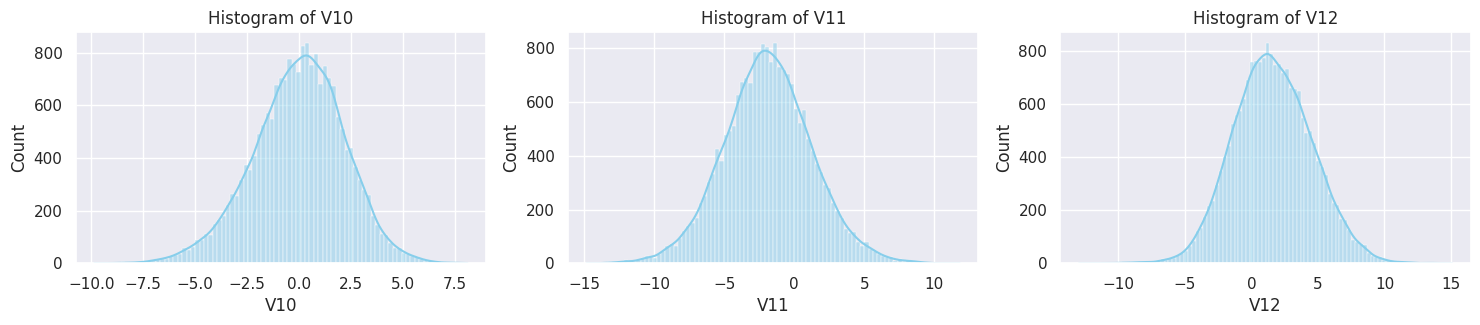

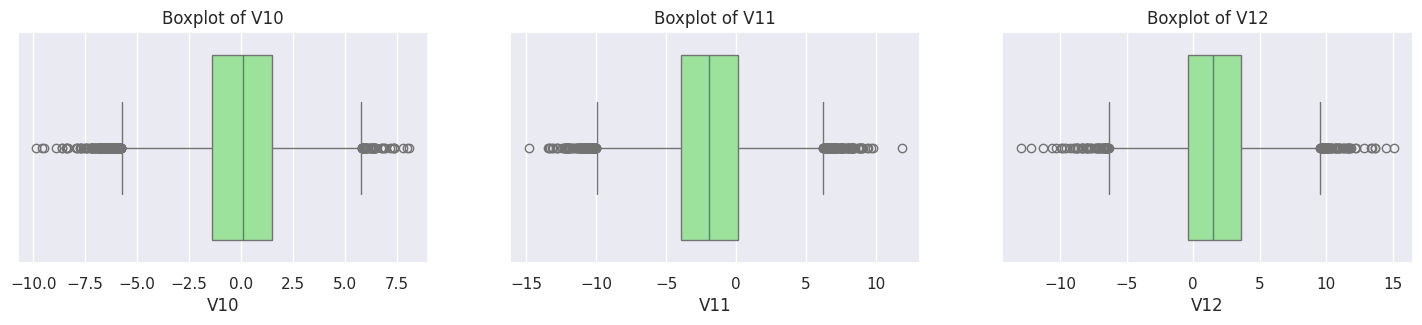

In [22]:
histplot_boxplot(df, ['V10', 'V11', 'V12'])

**V10 :**
- Distribution is approximately normal (bell-shaped) and centered close to 0.
- Moderate spread, with most values lying between -4 and +4.
- Outliers are present on both sides (around -10 and +8).
- Appears fairly symmetric with no strong skewness.

**V11 :**
- Distribution is approximately normal and centered slightly below 0.
- Wider spread compared to V10.
- Most values are concentrated between -6 and +4.
- Contains several outliers on both ends (around -15 and +12).

**V12 :**
- Distribution is close to symmetric and bell-shaped, centered slightly above 0.
- Moderate-to-high spread, larger than V10 and comparable to V11.
- Most values fall between -5 and +8.
- Outliers are visible on both sides (around -13 and +15).

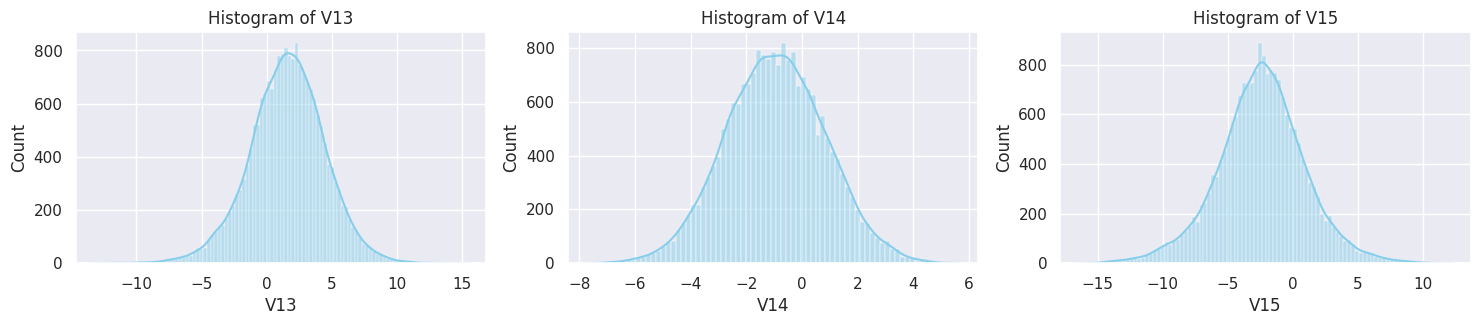

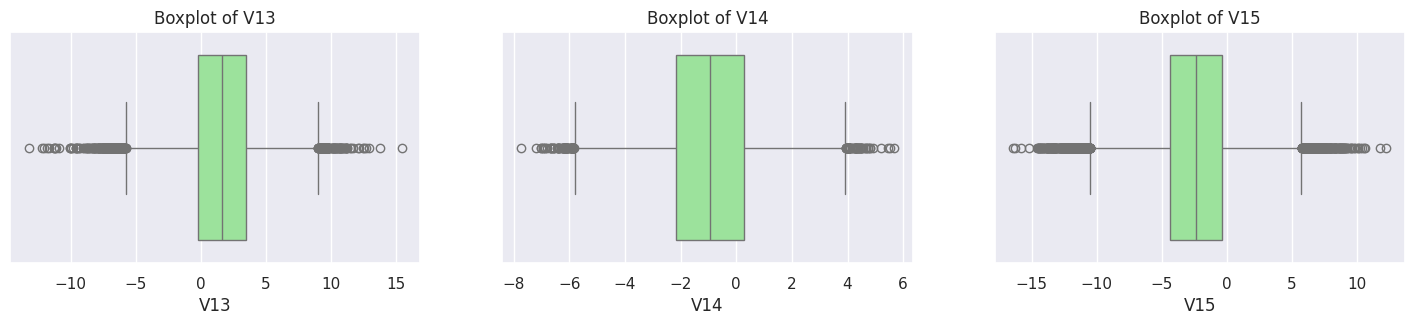

In [23]:
histplot_boxplot(df, ['V13', 'V14', 'V15'])

**V13 :**
- Distribution is approximately normal (bell-shaped) and centered slightly above 0.
- Moderate-to-high spread, with most values concentrated between -4 and +8.
- Outliers are present on both sides (around -13 and +16).
- Slight positive shift compared to V14 and V15.

**V14 :**
- Distribution is approximately normal and centered slightly below 0.
- Narrowest spread among V13, V14, and V15.
- Most values lie between -4 and +3.
- Outliers exist on both sides (around -8 and +6).
- Appears fairly symmetric with limited skewness.

**V15 :**
- Distribution is approximately normal and centered below 0.
- Wider spread than V14 and comparable to V13.
- Most values are concentrated between -7 and +4.
- Contains several outliers on both ends (around -16 and +13).
- Shows a slight negative shift in its distribution.

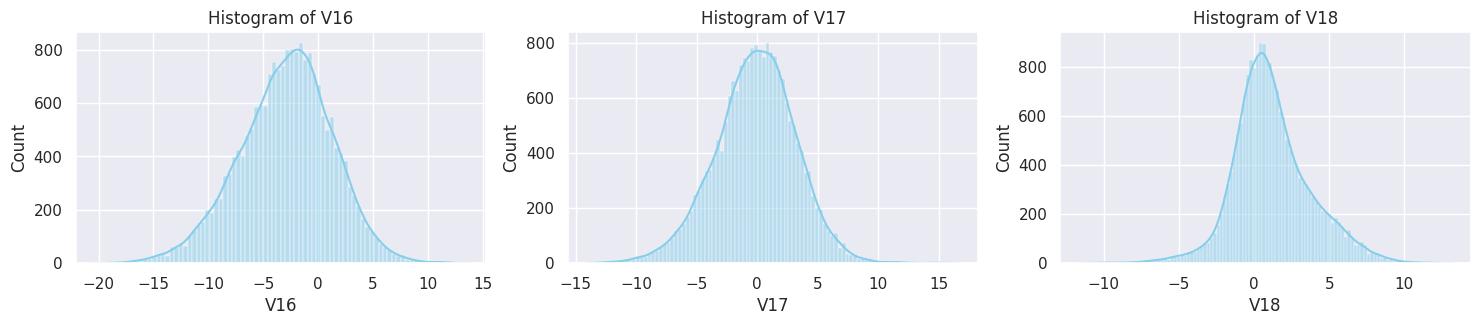

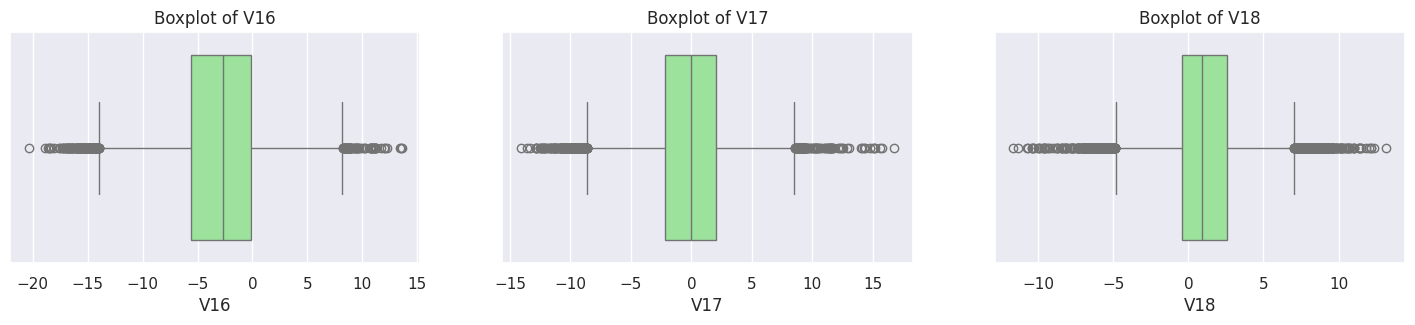

In [24]:
histplot_boxplot(df, ['V16', 'V17', 'V18'])

**V16 :**
- Distribution: Approximately normal (bell-shaped) and centered below 0, with a clear negative shift (peak around -2).
- Spread: Relatively wide spread, with the majority of the data concentrated be tween -6 and +2.
- Outliers: Present on both sides, extending significantly down to around -20 on the lower end and up to around +14 on the upper end.

**V17 :**
- Distribution: Highly symmetric and approximately normal, centered almost perfectly at 0.
- Spread: Moderate-to-high spread, with most values concentrated tightly between -2.5 and +2.5.
- Outliers: Visible on both tails, stretching down to approximately -14 and up to around +16.

**V18 :**
- Distribution: Approximately normal but displays a slight right-skew (positive skew), centered slightly above 0 (peak around +1).
- Spread: Moderate spread, with the bulk of the data falling between -1.5 and +4.
- Outliers: Present on both ends, with a heavier trail of outliers extending further to the positive side (up to around +13) compared to the negative side (down to around -11).


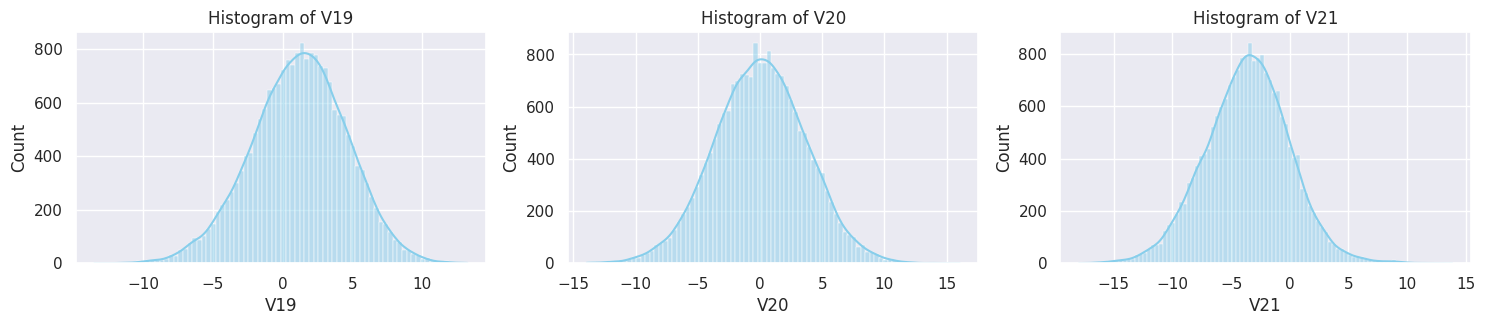

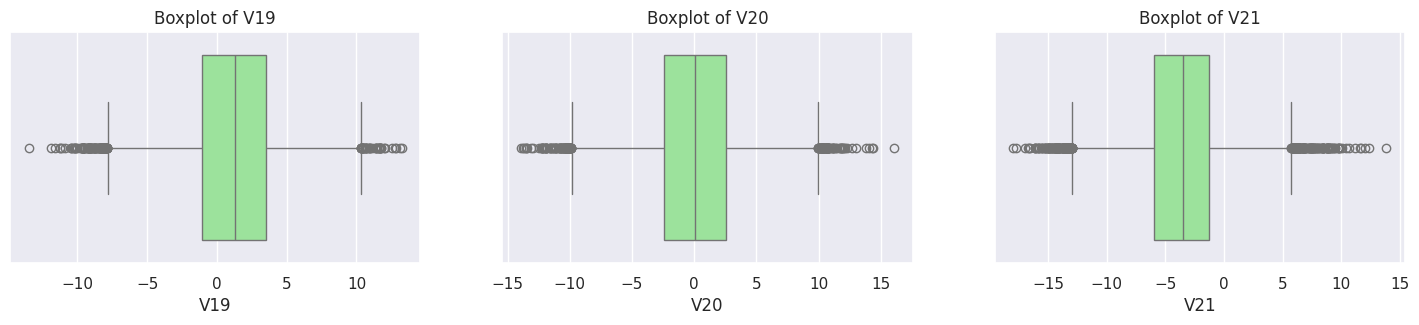

In [25]:
histplot_boxplot(df, ['V19', 'V20', 'V21'])

**V19 :**
-Distribution: Approximately normal (bell-shaped) and centered slightly above 0, showing a clear positive shift (peak around +2).
- Spread: Moderate spread, with the interquartile range (the bulk of the data) falling between -1 and +4.
- Outliers: Present on both sides, stretching down to roughly -13 on the lower end and extending up to about +13 on the upper end.

**V20 :**
- Distribution: Highly symmetric and approximately normal, centered almost perfectly at 0.
- Spread: Moderate-to-high spread, with most values concentrated between -2.5 and +2.5.
- Outliers: Visible on both tails, extending down to approximately -14 and stretching up past +15 on the positive side.

**V21 :**
- Distribution: Approximately normal but centered noticeably below 0, with a clear negative shift (peak around -3.5).
- Spread: Similar spread to V19 and V20, with the main concentration of data lying between -6 and -1.
- Outliers: Present on both ends, dropping down past -17 on the negative side and reaching up to around +14 on the positive side.

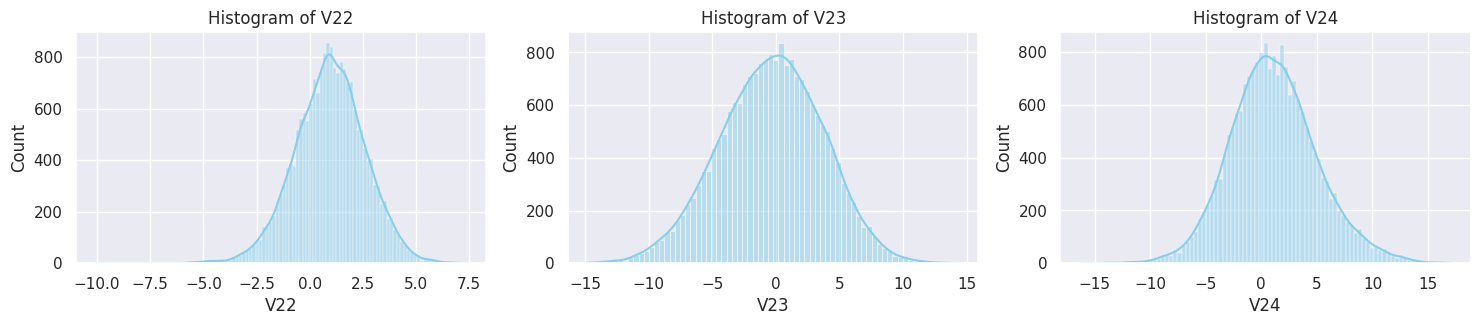

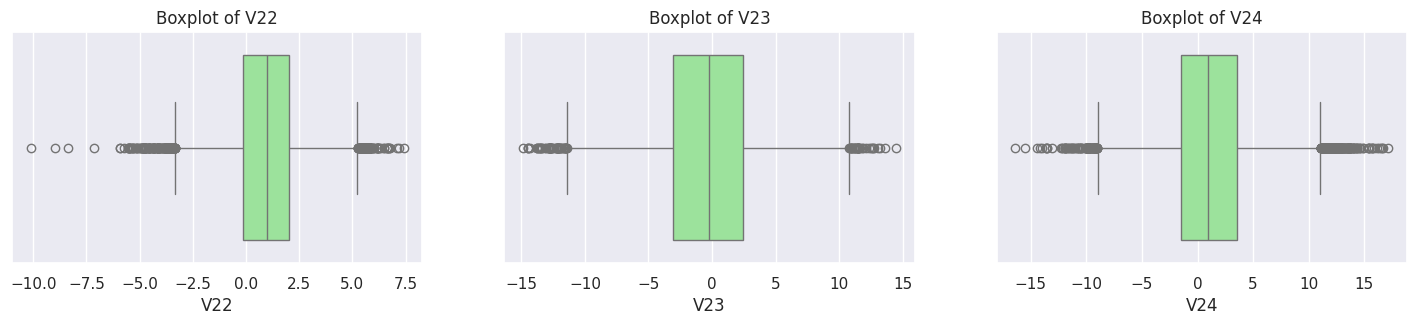

In [26]:
histplot_boxplot(df, ['V22', 'V23', 'V24'])

**V22 :**
- Distribution: Approximately normal (bell-shaped) and centered slightly above 0, showing a slight positive shift (peak around +1).
- Spread: Narrowest spread among the three variables, with the bulk of the data tightly concentrated between 0 and +2.
- Outliers: Present on both sides, extending notably down to around -10 on the lower end and up to around +7.5 on the upper end.

**V23 :**
- Distribution: Highly symmetric and approximately normal, centered almost perfectly at 0.
- Spread: Wide spread, with most values concentrated between -3 and +2.5.
- Outliers: Visible on both tails, stretching down to approximately -15 and up to around +14.

**V24 :**
- Distribution: Approximately normal and centered slightly above 0 (peak around +1).
- Spread: Moderate-to-high spread, with the interquartile range falling between -1.5 and +3.5.
- Outliers: Present on both ends, dropping down to around -16 on the negative side and reaching up to approximately +17 on the positive side.

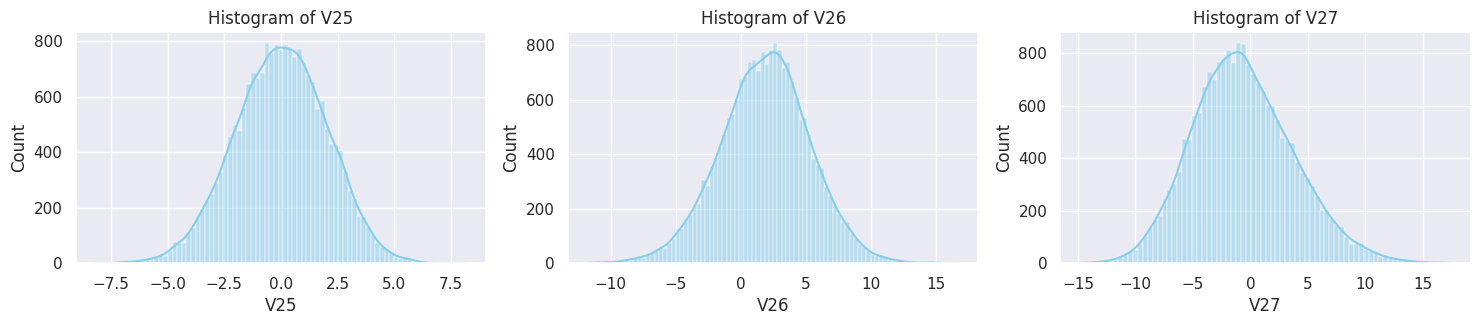

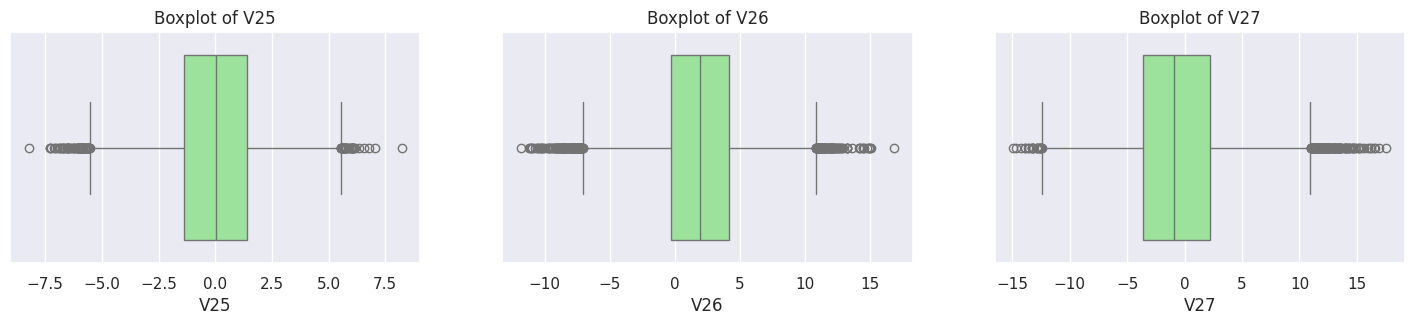

In [27]:
histplot_boxplot(df, ['V25', 'V26', 'V27'])

**V25 :**
- Distribution: Highly symmetric and approximately normal, centered almost perfectly at 0.
- Spread: Narrowest spread among the three variables, with the bulk of the data (interquartile range) closely packed between -1.5 and +1.5.
- Outliers: Present on both sides, stretching down to roughly -8.5 on the lower end and up to around +8.5 on the upper end.

**V26 :**
- Distribution: Approximately normal (bell-shaped) and centered above 0, showing a distinct positive shift (peak around +2.5).
- Spread: Moderate spread, with most values concentrated between 0 and +4.5.
- Outliers: Visible on both tails, extending down past -11 on the negative side and reaching up to approximately +17 on the positive side.

**V27 :**
- Distribution: Approximately normal but centered below 0, displaying a noticeable negative shift (peak around -1.5).
- Spread: Moderate-to-high spread, with the core data concentration falling between -4 and +2.5.
- Outliers: Present on both ends, dropping down to around -15 on the lower end and extending out past +17 on the upper end.

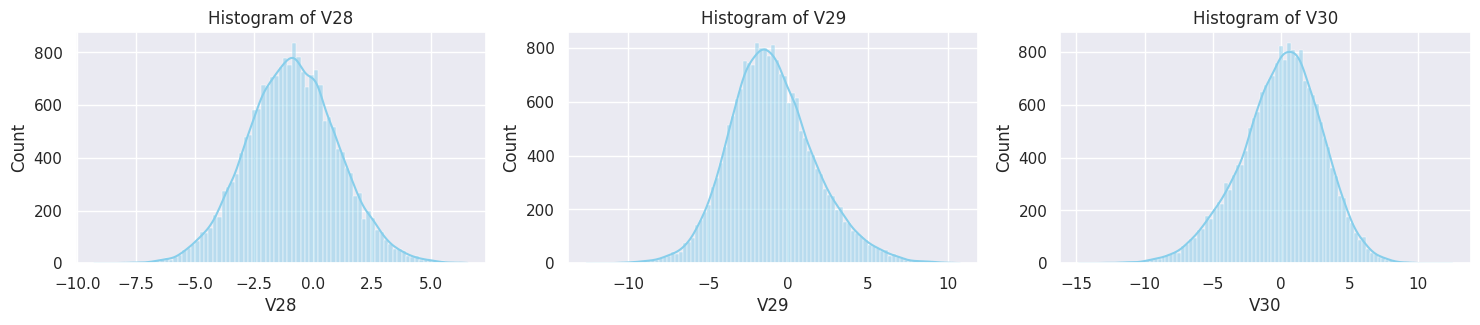

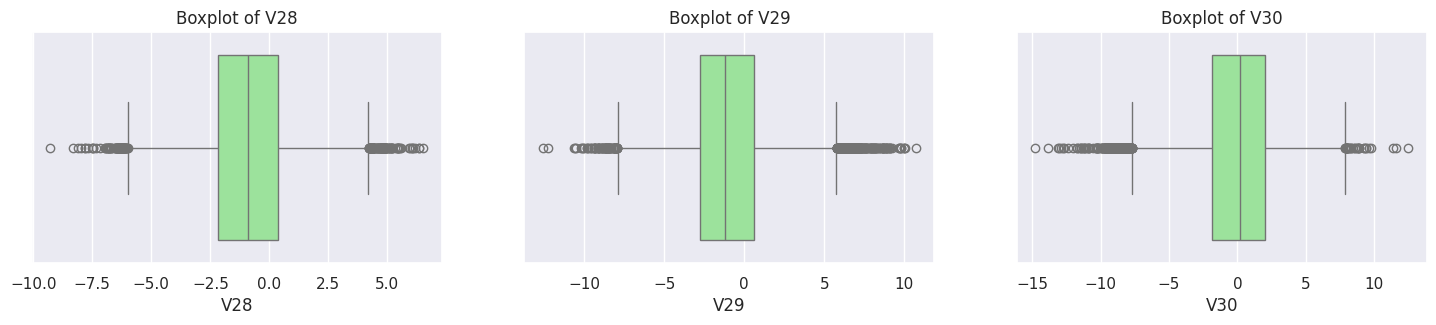

In [28]:
histplot_boxplot(df, ['V28', 'V29', 'V30'])

**V28 :**
- Distribution: Approximately normal (bell-shaped) and centered slightly below 0, showing a minor negative shift (peak around -1).
- Spread: Narrowest spread among the three variables, with the core data concentration (interquartile range) closely bounded between -2.5 and +0.5.
- Outliers: Present on both sides, extending down past -9 on the lower end and up to around +7 on the upper end.

**V29 :**
- Distribution: Approximately normal but centered noticeably below 0, displaying a clear negative shift (peak around -1.5).
- Spread: Moderate spread, with the majority of the values falling between -3 and +1.
- Outliers: Visible on both tails, stretching down to roughly -13 on the negative side and reaching up past +11 on the positive side.

**V30 :**
- Distribution: Approximately normal and centered slightly above 0, showing a minor positive shift (peak around +1).
- Spread: Moderate-to-high spread, with most values concentrated between -2 and +3.5.
- Outliers: Present on both ends, dropping down to around -15 on the lower end and extending out to approximately +13 on the upper end.

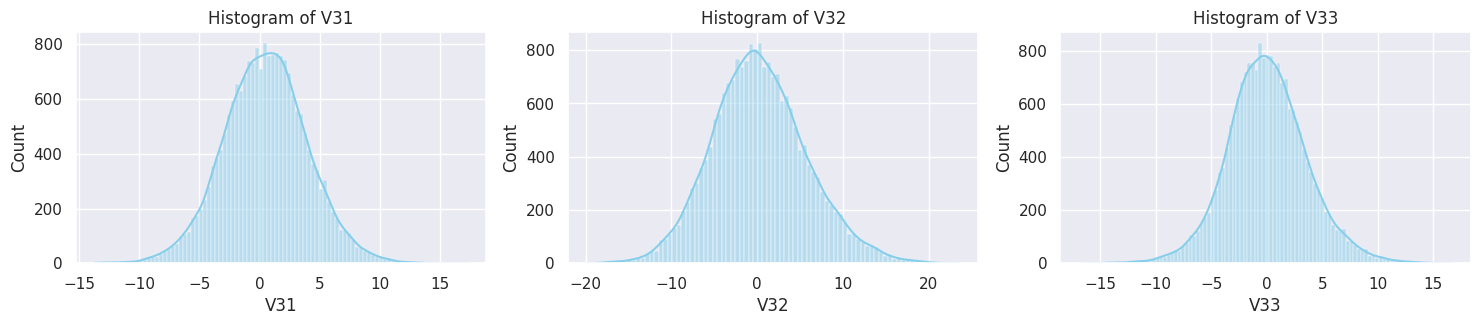

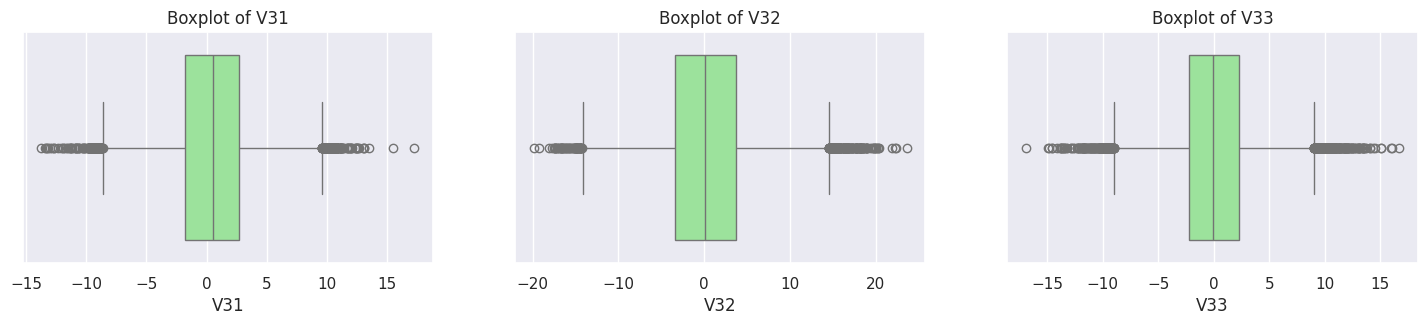

In [29]:
histplot_boxplot(df, ['V31', 'V32', 'V33'])

**V31 :**
- Distribution: Approximately normal (bell-shaped) and centered slightly above 0, showing a minor positive shift (peak around +1).
- Spread: Moderate spread, with the interquartile range (the green box) concentrated between -2 and +3.
- Outliers: Present on both sides, extending down to around -14 on the lower end and stretching up to approximately +17 on the upper end.

**V32 :**
- Distribution: Highly symmetric and approximately normal, centered almost perfectly at 0.
- Spread: Wide spread—the widest among the three variables—with the core data falling between -3.5 and +3.5, and tails expanding significantly.
- Outliers: Visible on both tails, stretching down past -20 on the negative side and reaching up past +24 on the positive side.

**V33 :**
- Distribution: Approximately normal but centered slightly below 0, displaying a minor negative shift (peak around -0.5).
- Spread: Narrowest spread among the three features, with the bulk of the data tightly concentrated between -2.5 and +2.5.
- Outliers: Present on both ends, dropping down to around -15 on the lower end and extending out to approximately +16 on the upper end.

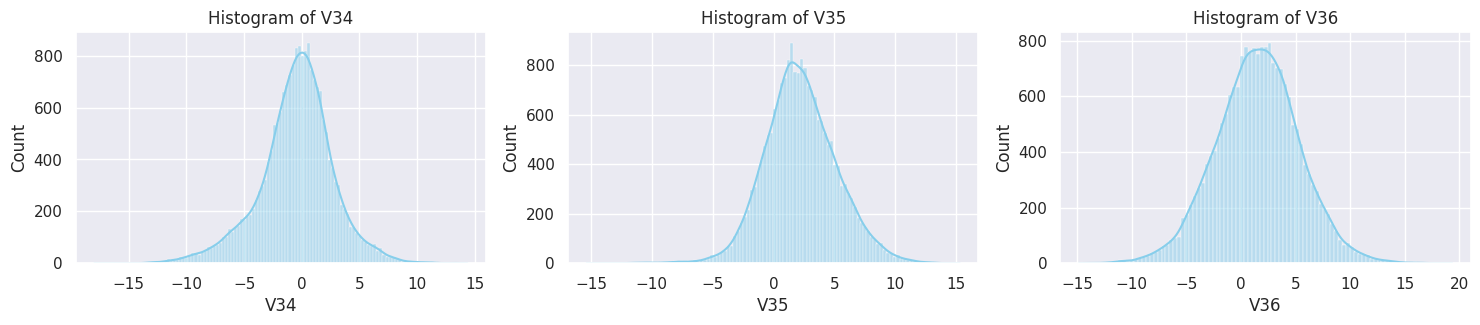

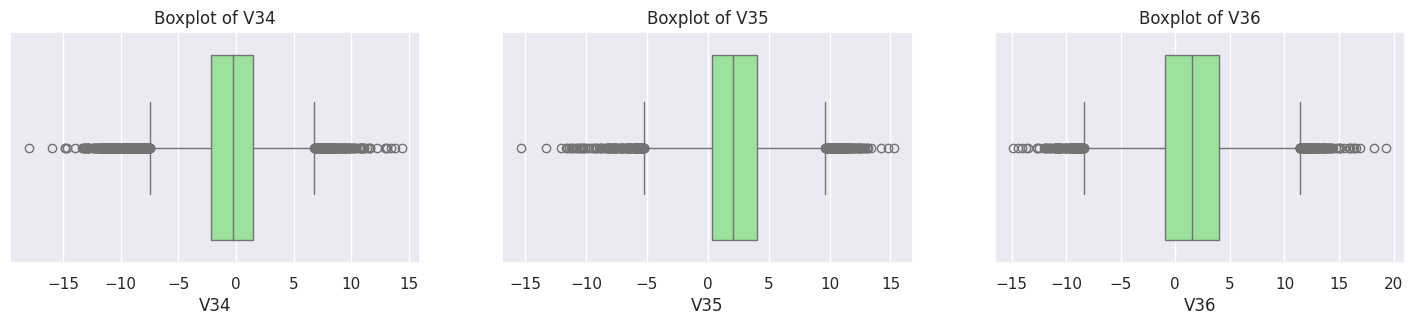

In [30]:
histplot_boxplot(df, ['V34', 'V35', 'V36'])

**V34 :**
- Distribution: Approximately normal but centered slightly below 0, displaying a minor negative shift (peak around -0.5).
- Spread: Narrowest spread among the three variables, with the core data concentration closely bounded between -2 and +1.5.
- Outliers: Present on both sides, stretching significantly down past -18 on the lower end and extending up to around +14 on the upper end.

**V35 :**
- Distribution: Approximately normal (bell-shaped) and centered above 0, showing a distinct positive shift (peak around +2).
- Spread: Moderate spread, with the interquartile range concentrated between +0.5 and +4.
- Outliers: Visible on both tails, dropping down to around -15 on the negative side and reaching up past +15 on the positive side.

**V36 :**
- Distribution: Approximately normal and centered noticeably above 0, displaying a clear positive shift (peak around +2.5).
-Spread: Wide spread—the widest among the three features—with the bulk of the data falling between -1 and +5.5.
- Outliers: Present on both ends, dropping down to around -15 on the lower end and extending out past +19 on the upper end.

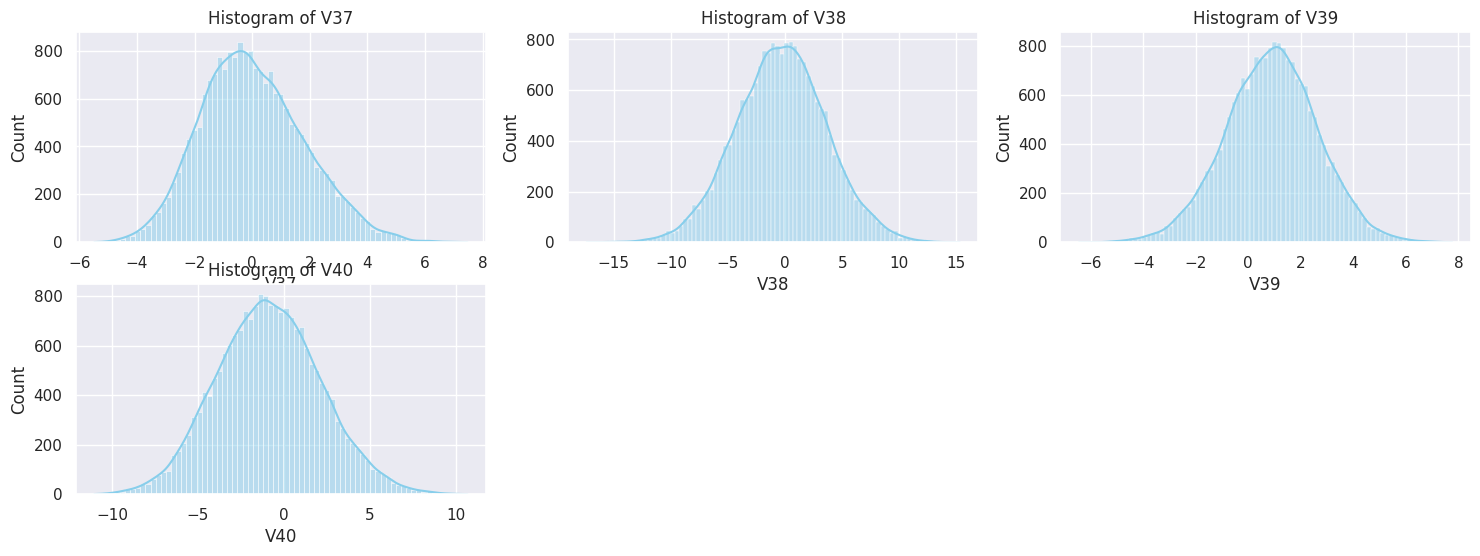

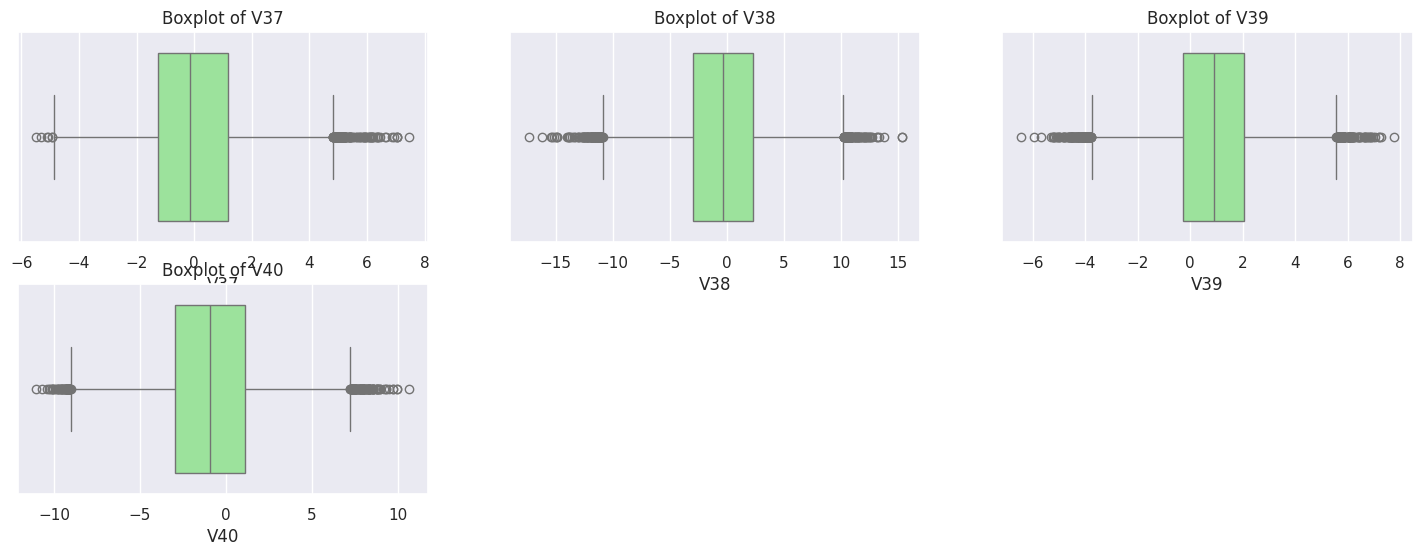

In [31]:
histplot_boxplot(df, ['V37', 'V38', 'V39', 'V40'])

**V37 :**
- Distribution: Approximately normal (bell-shaped) and centered slightly below 0, showing a minor negative shift (peak around -0.5).
- Spread: Narrowest spread among the four variables, with the core data concentration closely bounded between -1.5 and +1.
- Outliers: Present on both sides, extending down to around -5.5 on the lower end and stretching up past +7.5 on the upper end.

**V38 :**
- Distribution: Highly symmetric and approximately normal, centered almost perfectly at 0.
- Spread: Wide spread—the widest among the four variables—with the interquartile range concentrated between -3 and +2.5.
- Outliers: Visible on both tails, stretching down past -15 on the negative side and reaching up past +15 on the positive side.

**V39 :**
- Distribution: Approximately normal and centered noticeably above 0, displaying a clear positive shift (peak around +1).
- Spread: Moderate spread, with the bulk of the data falling between -0.5 and +2.
- Outliers: Present on both ends, dropping down to around -6 on the lower end and extending out past +7.5 on the upper end.

**V40 :**
- Distribution: Approximately normal but centered visibly below 0, displaying a distinct negative shift (peak around -1.5).
- Spread: Moderate-to-high spread, with the core data falling between -3 and +1.5.
- Outliers: Present on both sides, stretching down past -11 on the negative side and reaching up past +10 on the positive side.


### **Bivaraite Analysis**

In [32]:
# we are going to find correaltion between the variables. but we have 40 varibale so it has difficult to see in visualization so we created a correlation table for attribute & target variable
# & filterout only top 20 Sensores.

corr_table = (
    df.corr()['Target']
      .abs()
      .sort_values(ascending=False)
      .reset_index()
)

corr_table.columns = ['Feature','Correlation']

print(corr_table.head(20))

   Feature  Correlation
0   Target     1.000000
1      V18     0.293340
2      V21     0.256411
3      V15     0.249118
4       V7     0.236907
5      V16     0.230507
6      V39     0.227264
7      V36     0.216453
8       V3     0.213855
9      V28     0.207359
10     V11     0.196715
11     V26     0.180469
12     V34     0.153854
13     V35     0.145603
14     V13     0.139718
15     V31     0.136951
16      V8     0.135996
17     V22     0.134727
18     V14     0.117586
19      V4     0.110786


Above top 20 variables are positive correlation with target value.

In [33]:
# list out the top 20 sensores from above code where they are highly correlated with target.
col_list = corr_table['Feature'].tolist()

# filtring required columns
top_20_sensores = df[col_list]

top_20_sensores.head()

,Target,V18,V21,V15,V7,V16,V39,V36,V3,V28,V11,V26,V34,V35,V13,V31,V8,V22,V14,V4,V29,V33,V5,V24,V17,V1,V23,V20,V19,V10,V30,V32,V12,V27,V9,V40,V37,V38,V25,V2,V6
0,0,2.914097,-2.388299,-3.375815,-2.910870,-3.047303,2.950578,6.667486,3.101546,0.726218,-5.714719,-2.510846,2.846296,2.235198,0.981251,1.667098,0.050714,0.646388,1.417884,0.506130,-3.982187,-1.690440,-0.221083,3.132986,0.306194,-4.464606,-1.190508,4.394876,2.269979,3.761892,-1.072638,3.059700,0.735893,-0.036744,-1.522351,-3.480324,0.443809,-2.369169,0.665277,-4.679129,-2.032511
1,0,0.907716,-3.065122,0.193223,0.732600,-4.769379,-0.386345,-2.297780,0.909671,-0.585712,1.914465,3.625036,-2.467514,1.894599,-1.255259,0.024883,-4.332135,1.596647,-2.706522,-1.367528,0.783034,3.032780,0.332016,1.766444,-2.205319,3.365912,-1.757311,-5.833678,0.756894,-0.101080,-0.201217,-1.795474,-0.951458,1.500346,0.565695,0.616242,-1.731048,5.908837,-0.267098,3.653381,2.358938
2,0,3.688534,-2.143026,-3.163804,-2.098941,-4.247825,3.839160,5.360850,0.634031,1.134404,-0.770673,-4.550695,4.086219,2.292138,1.144261,-1.600395,-3.173204,1.650120,0.943301,-2.418815,-2.033531,0.803550,-1.773827,1.679910,-4.038909,-3.831843,-1.660592,1.059002,3.311196,5.392621,0.840839,-0.257101,1.106718,3.738779,-2.081860,-4.309402,0.351993,2.940021,-0.450782,-5.824444,1.016824
3,0,-1.281536,-3.516555,-0.453717,0.207309,-3.174046,3.101430,5.550100,7.046143,-2.308536,-3.053023,5.294642,1.363769,0.622714,2.704527,4.948770,-2.493629,-1.206011,-0.636086,-1.147285,-3.962977,-2.577474,0.083080,-1.817653,-3.404347,1.618098,-5.627854,-1.951778,1.582104,2.118578,-6.028730,-3.584425,0.459719,4.748137,0.344926,-1.277378,-1.526796,0.138853,2.124142,1.888342,-1.529780
4,0,3.734452,-0.886667,-2.632684,0.205433,4.184447,-3.644622,-3.229763,-3.758361,-3.382967,1.998347,4.582065,-10.068689,1.222987,0.709113,2.044184,4.848994,2.061694,-1.989432,-2.982897,5.106507,6.629213,3.792714,4.489976,2.245356,-0.111440,9.445586,-5.379918,-6.312766,-6.220023,6.787513,8.265896,4.723757,-8.780422,-1.854920,6.510338,1.686909,-2.163896,-3.945144,3.872488,0.544960


In [34]:
# here we are calculating the average value for each sensor seprately for target 0 & 1
# high differance is either positive side or negative side it is influencing the target value & lower difference is not contributing that much on target value.
target_mean = df.groupby('Target').mean().T

target_mean.columns = ['Target_0','Target_1']

target_mean['Difference'] = (
    target_mean['Target_1']
    - target_mean['Target_0']
)

target_mean.sort_values(
    'Difference',
    ascending=False
)

,Target_0,Target_1,Difference
V16,-3.161114,1.089148,4.250262
V21,-3.832999,0.162445,3.995444
V15,-2.617588,1.032767,3.650355
V11,-2.044374,0.639956,2.684329
V34,-0.581442,1.558006,2.139448
V8,-0.656842,1.300756,1.957598
V7,-0.980488,0.842285,1.822773
V28,-0.979610,0.757184,1.736794
V4,-0.175306,1.485127,1.660432
V29,-1.056123,0.214105,1.270228


**Differenace On Postive Side :** V16, V21, V15, V11, V34 sensore having positive difference & highly influencing the Target.

**Differance On Negative Side :** V31, V26, V3, V18, V36 sensores having negative difference but impactful on target.

**Difference near to Zero :** Those sensore are near to Zero. they are behaves like both classes and may be weak prediction power.

### **Missing data Treatment :**

In [35]:
null = df.columns[df.isnull().sum() > 0]
null

Index(['V1', 'V2'], dtype='object')

Here in tbale Columns V1 & V2 has null values.

In [36]:
# null percentage
V1_null_perctage = (df['V1'].isnull().sum() / len(df)) * 100
V2_null_perctage = (df['V2'].isnull().sum() / len(df)) * 100

print(f"V1 null Pecentage {V1_null_perctage} \nV2 null percentage {V2_null_perctage}")

V1 null Pecentage 0.09 
V2 null percentage 0.09


So, here our null percentage is around 0.09% this is extremly small, we can drop the null rows but dropping leads to information lack & also we have high amount of outliers so cant use mean so we use Median as null value replacement.

In [37]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy = 'median')

df[['V1', 'V2']] = imputer.fit_transform(df[['V1', 'V2']])

In [38]:
# now we are checking the null value are present or not

df.isnull().sum()

,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


After treating null values then our table not containing the null values.

### **Data Preprocessing**

- Before training the Deep learning model, we need to prepare data properly.
- ince all the features in our dataset are already in numerical format, we don't need to perform any encoding.

- In this step we will,
1. split the data into training , validation & test sets using a 70:15:15 ratio. This helps us train the model, tune it, and finally evaluate its performance on unseen data.
2. Scale the features using RobustScaler to bring all values into a similar range, which helps the model learn more effectively. Below table helps to select the Scale to normalize the values in certain range

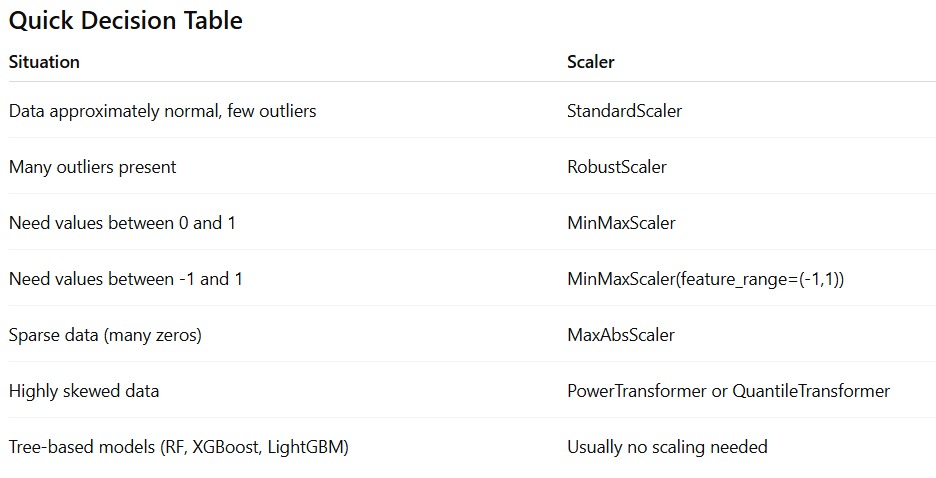

### **Train, Test, Validation Split**

**Why Split the Data into Train, Validation, and Test?**
- **Train Set:** Used to fit the model and learn patterns.
- **Validation Set:** Helps tune model parameters and prevent overfitting.
- **Test Set:** Used only at the end to evaluate model performance on unseen data.

In [39]:
# splitting data into train, validation, test sets (70:15:15 ratio)

X = df.drop('Target', axis = 1)
y = df['Target']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)
X_val, X_test, y_val, y_test = train_test_split( X_temp, y_temp, test_size = 0.5, random_state = 42, stratify = y_temp)

### **Normalizing the numerical variables**

In [40]:
  # normalizing the feature using RobustScaler

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.fit_transform(X_val)
X_test = scaler.fit_transform(X_test)

Why RobustScaler :    
- Since our table contains high amount of outliers so Normalizing values in table with RobustScaler is very optimized way. This scaler work well on outliers data.

In [41]:
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (14000, 40)
X_val shape: (3000, 40)
X_test shape: (3000, 40)
y_train shape: (14000,)
y_val shape: (3000,)
y_test shape: (3000,)


### **Model Building**


With the data prepared, we now to building and training Artificial Neural Networks (ANNs) to predict component failure . We'll experiment with different ANN architectures to find the most effective setup.


What We’ll Do:
1. Define the ANN model – Try out various architectures.
2. Train the model – Use training data to learn patterns.
3. Validate and test – Evaluate the model on unseen data.

**Utility Function for Graph**

In [42]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend

**Creating Dataframe to store result of trained model**

In [43]:
# Create a blank DataFrame to store the training and validation evaluation results of different models.

evaluation_results = pd.DataFrame(columns=['Model', '# hidden layers', '# neurons hidden layer', 'activation function hidden layer', '# epochs', 'batch size', 'Train_Loss',
                                           'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1', 'Val_Loss', 'Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1'])

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1


# **Model 1**

we build this nural netwrok mdoel using simple architecture.

- Input Layer: The input shape is determined by the number of features in the training data, X_train​.
- Output Layer: One Dense layer with 1 unit and a sigmoid activation to handle binary classification.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

The model is trained for 25 epochs using a full batch gradient descent approach, as the batch_size is set to X_train.shape[0] (the entire training dataset size).

In [44]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [45]:
# intializig the nural network
model1 = Sequential()

# adding the dense layer with sigmoid activation function.
model1.add(Dense(1, activation = 'sigmoid', input_shape=(X_train.shape[1],)))
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
# defining SGD as the optimizer to be used
optimizer = 'sgd'

# defining binary crossentropy as the loss function
loss = 'binary_crossentropy'

#Compiling the model.
model1.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [47]:
epochs = 25   # training the model for 25 epochs
batch_size = X_train.shape[0]    # setting the batch size equal to the number of rows

# time.time() returns the time in seconds
start = time.time()

# Fitting the model.
history1 = model1.fit(X_train, y_train,
                      validation_data=(X_val,y_val) ,
                      batch_size=batch_size,
                      epochs=epochs)

# time.time() returns the time in seconds
end = time.time()

Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - binary_accuracy: 0.5004 - loss: 0.8393 - precision: 0.0369 - recall: 0.3192 - val_binary_accuracy: 0.5130 - val_loss: 0.8204 - val_precision: 0.0418 - val_recall: 0.3533
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - binary_accuracy: 0.5025 - loss: 0.8350 - precision: 0.0370 - recall: 0.3179 - val_binary_accuracy: 0.5137 - val_loss: 0.8162 - val_precision: 0.0418 - val_recall: 0.3533
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - binary_accuracy: 0.5051 - loss: 0.8306 - precision: 0.0372 - recall: 0.3179 - val_binary_accuracy: 0.5170 - val_loss: 0.8121 - val_precision: 0.0421 - val_recall: 0.3533
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - binary_accuracy: 0.5071 - loss: 0.8263 - precision: 0.0375 - recall: 0.3192 - val_binary_accuracy: 0.5197 - val_loss: 0.8080 - val_precision: 0.0424 - val_recall: 0.3533
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - binary_accuracy: 0.5088 - loss: 0.8220 - precision: 0.0375 - recal

In [48]:
print("Time taken in seconds ",end-start)

Time taken in seconds  3.7920751571655273


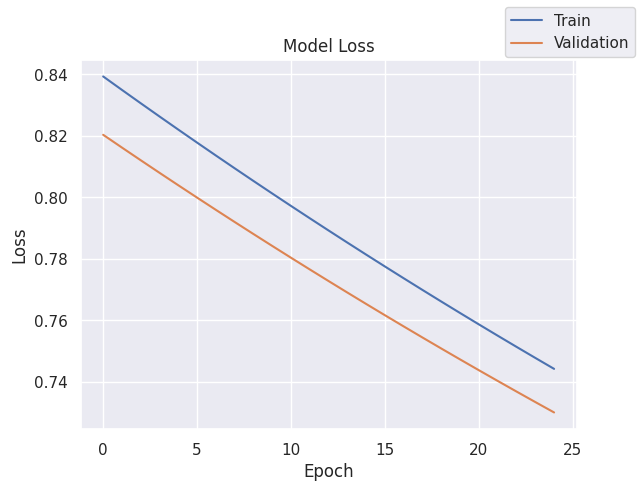

In [49]:
# plotting graph
plot(history1,'loss')

In [50]:
evaluation_results.loc[0] = [
    'Model 1',
    '-',
    '-',
    '-',
    epochs,
    batch_size,
    history1.history["loss"][-1],
    history1.history["val_binary_accuracy"][-1],
    history1.history["precision"][-1],
    history1.history["recall"][-1],
    2 * (history1.history["precision"][-1] * history1.history["recall"][-1]) / (history1.history["precision"][-1] + history1.history["recall"][-1] + 1e-7),
    history1.history["val_loss"][-1],history1.history["val_binary_accuracy"][-1],
    history1.history["val_precision"][-1],
    history1.history["val_recall"][-1],
    2 * (history1.history["val_precision"][-1] * history1.history["val_recall"][-1]) / (history1.history["val_precision"][-1] + history1.history["val_recall"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171


- Since it's a very simple neural network with only 8 trainable parameters, limiting its ability to capture complex patterns, the scores aren't good.
- The loss graph shows a straight downward line that has not yet flattened (converged). This indicates the model is still learning and was stopped too early.
- With using batch_size = X_train.shape[0] (14000) and epochs=25, the weights were updated only 25 times in total. This is insufficient for the SGD optimizer to find the optimal solution.
- For the next model we should try increasing the epochs.

# **Model 2**

We built our second neural network model with the following changes:

- The same architecture as the first model.
- The model is trained for 50 epochs instead of 25.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

The model is trained for 50 epochs using a full batch gradient descent approach, as the batch_size is set to X_train.shape[0] (the entire training dataset size).

In [51]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [52]:
#Initializing the neural network
model2 = Sequential()

model2.add(Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))

In [53]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [54]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'  # defining binary crossentropy as the loss function

model2.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [55]:
epochs = 50
batch_size = X_train.shape[0]

start = time.time()
history2 = model2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 571ms/step - binary_accuracy: 0.5487 - loss: 0.8940 - precision: 0.0435 - recall: 0.3398 - val_binary_accuracy: 0.5347 - val_loss: 0.8930 - val_precision: 0.0390 - val_recall: 0.3114
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - binary_accuracy: 0.5499 - loss: 0.8885 - precision: 0.0436 - recall: 0.3398 - val_binary_accuracy: 0.5363 - val_loss: 0.8877 - val_precision: 0.0405 - val_recall: 0.3234
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - binary_accuracy: 0.5509 - loss: 0.8830 - precision: 0.0439 - recall: 0.3411 - val_binary_accuracy: 0.5380 - val_loss: 0.8823 - val_precision: 0.0407 - val_recall: 0.3234
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - binary_accuracy: 0.5521 - loss: 0.8776 - precision: 0.0440 - recall: 0.3411 - val_binary_accuracy: 0.5400 - val_loss: 0.8770 - val_precision: 0.0409 - val_recall: 0.3234
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - binary_accuracy: 0.5534 - loss: 0.8723 - precision: 0.0441 - re

In [56]:
print("Time taken in seconds ",end-start)

Time taken in seconds  5.2455034255981445


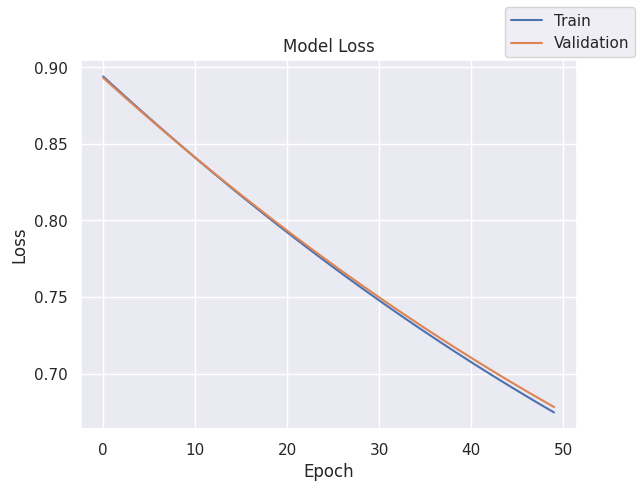

In [57]:
plot(history2,'loss')

In [58]:
evaluation_results.loc[1] = [
    'Model 2',
    '-',
    '-',
    '-',
    epochs,
    batch_size,
    history2.history["loss"][-1],
    history2.history["val_binary_accuracy"][-1],
    history2.history["precision"][-1],
    history2.history["recall"][-1],
    2 * (history2.history["precision"][-1] * history2.history["recall"][-1]) / (history2.history["precision"][-1] + history2.history["recall"][-1] + 1e-7),
    history2.history["val_loss"][-1],history2.history["val_binary_accuracy"][-1], history2.history["val_precision"][-1],
    history2.history["val_recall"][-1],
    2 * (history2.history["val_precision"][-1] * history2.history["val_recall"][-1]) / (history2.history["val_precision"][-1] + history2.history["val_recall"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600


- The loss curve is still a smooth, linear slope downwards. This indicates the model is still "learning" (lowering loss), but because it updates so infrequently (once per epoch), it is moving very slowly.

- The loss has dropped, and is lower than Model 1.

- Model 2 shows a drastic jump in accuracy compared to Model 1, but a collapse in actual utility.

Accuracy: Increased by a lot

Recall: Went down slightly

Precision: Decreased slightly

- It might beneficial to change the batch size, in order to increase the number of updates to the model weights.

# **Model 3**

We built our third neural network model with the following changes:

- The same architecture as the first model.
- The batch size is set to 32.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training

Metrics: The model is evaluated using the Recall metric.

The model is trained for 50 epochs using a stochastic gradient descent approach, with batch_size = 32

In [59]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [60]:
#Initializing the neural network
model3 = Sequential()
model3.add(Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))

In [61]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model3.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [63]:
epochs = 50
batch_size = 32

start = time.time()
history3 = model3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8514 - loss: 0.4545 - precision: 0.1374 - recall: 0.3179 - val_binary_accuracy: 0.9487 - val_loss: 0.3046 - val_precision: 0.7241 - val_recall: 0.1257
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9504 - loss: 0.2462 - precision: 0.8534 - recall: 0.1274 - val_binary_accuracy: 0.9513 - val_loss: 0.2159 - val_precision: 0.9200 - val_recall: 0.1377
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - binary_accuracy: 0.9521 - loss: 0.1922 - precision: 0.9213 - recall: 0.1506 - val_binary_accuracy: 0.9530 - val_loss: 0.1815 - val_precision: 0.9643 - val_recall: 0.1617
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9558 - loss: 0.1681 - precision: 0.9489 - recall: 0.2149 - val_binary_accuracy: 0.9537 - val_loss: 0.1633 - val_precision: 0.9667 - val_recall: 0.1737
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9584 - loss: 0.1544 - precision

In [64]:
print("Time taken in seconds ",end-start)

Time taken in seconds  59.53578066825867


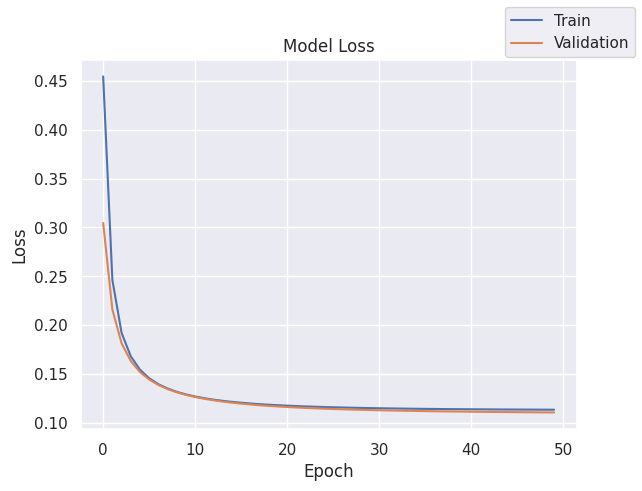

In [65]:
plot(history3,'loss')

In [66]:
evaluation_results.loc[2] = [
    'Model 3',
    '-',
    '-',
    '-',
    epochs,
    batch_size,
    history3.history["loss"][-1],
    history3.history["val_binary_accuracy"][-1],
    history3.history["precision"][-1],
    history3.history["recall"][-1],
    2 * (history3.history["precision"][-1] * history3.history["recall"][-1]) / (history3.history["precision"][-1] + history3.history["recall"][-1] + 1e-7),
    history3.history["val_loss"][-1],
    history3.history["val_binary_accuracy"][-1],
    history3.history["val_precision"][-1],
    history3.history["val_recall"][-1],
    2 * (history3.history["val_precision"][-1] * history3.history["val_recall"][-1]) / (history3.history["val_precision"][-1] + history3.history["val_recall"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600
2,Model 3,-,-,-,50,32,0.113492,0.965000,0.865741,0.481338,0.618693,0.110682,0.965000,0.836957,0.461078,0.594595


# **Model 4**

We built our fourth neural network model with the following changes:

- The same architecture as the first model.
- The batch size is set to 64.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training

Metrics: The model is evaluated using the Recall metric.

The model is trained for 50 epochs using a stochastic batch descent approach, with batch_size = 64

In [67]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [68]:
#Initializing the neural network
model4 = Sequential()
model4.add(Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))

In [69]:
model4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [70]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model4.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [71]:
epochs = 50
batch_size = 64

In [72]:
start = time.time()
history4 = model4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.7926 - loss: 0.5628 - precision: 0.0370 - recall: 0.1094 - val_binary_accuracy: 0.9450 - val_loss: 0.3938 - val_precision: 0.6250 - val_recall: 0.0299
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9476 - loss: 0.3311 - precision: 0.7654 - recall: 0.0798 - val_binary_accuracy: 0.9490 - val_loss: 0.2853 - val_precision: 0.9375 - val_recall: 0.0898
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9521 - loss: 0.2562 - precision: 0.9421 - recall: 0.1467 - val_binary_accuracy: 0.9517 - val_loss: 0.2351 - val_precision: 0.9583 - val_recall: 0.1377
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9537 - loss: 0.2180 - precision: 0.9574 - recall: 0.1737 - val_binary_accuracy: 0.9533 - val_loss: 0.2066 - val_precision: 0.9655 - val_recall: 0.1677
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9548 - loss: 0.1951 - precision

In [73]:
print("Time taken in seconds ",end-start)

Time taken in seconds  32.20575475692749


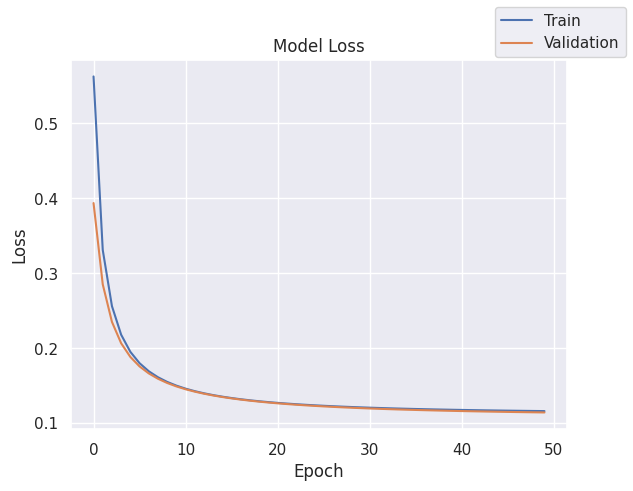

In [74]:
plot(history4,'loss')

In [75]:
evaluation_results.loc[3] = [
    'Model 4',
    '-',
    '-',
    '-',
    epochs,
    batch_size,
    history4.history["loss"][-1],
    history4.history["val_binary_accuracy"][-1],
    history4.history["precision"][-1],
    history4.history["recall"][-1],
    2 * (history4.history["precision"][-1] * history4.history["recall"][-1]) / (history4.history["precision"][-1] + history4.history["recall"][-1] + 1e-7),
    history4.history["val_loss"][-1],
    history4.history["val_binary_accuracy"][-1],
    history4.history["val_precision"][-1],
    history4.history["val_recall"][-1],
    2 * (history4.history["val_precision"][-1] * history4.history["val_recall"][-1]) / (history4.history["val_precision"][-1] + history4.history["val_recall"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600
2,Model 3,-,-,-,50,32,0.113492,0.965000,0.865741,0.481338,0.618693,0.110682,0.965000,0.836957,0.461078,0.594595
3,Model 4,-,-,-,50,64,0.116054,0.964333,0.889724,0.456885,0.603741,0.114240,0.964333,0.857143,0.431138,0.573705


- Loss Curve: The loss curve for this model looks almost identical to that of the previous model.
- Model Behavior: This model suffers from the same critical flaw as the previous one. Training and validation accuracy are high, but recall and precision for the positive class are effectively zero.
- Analysis: The matching accuracies for both models indicate they are behaving like dummy classifiers, predicting only the majority (negative) class for all inputs. The reported accuracy simply reflects the proportion of negative samples in the dataset.
- Comparison to Previous Model: The previous model, which used a smaller batch size, achieves a lower loss than this one, despite both behaving similarly in terms of predictions.
- Root Cause & Next Step: Because of the strong class imbalance, the model has collapsed into always predicting the negative class. As a next step, we should introduce class weights to penalize misclassification of the minority class and encourage the model to learn meaningful positive predictions.

# **Model 5**

We built our fifth neural network model with the following changes:

- Class Weights: We compute class weights to adjust the loss function, penalizing the model more heavily for misclassifying the minority class to ensure it learns distinct features for both.
- Batch size of 32 (We choose a batch size of 32 instead of 64, as the performace of Model 2 (Batch Size 32) was better than Model 3 (Batch Size 64). We will keep this the same for the rest of the models)
- The same architecture as the baseline model: Input Layer, and Output Layer with a sigmoid activation for binary classification

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

Metrics: The model is evaluated using the Recall metric.

The model is trained for 50 epochs using a stochastic batch descent approach, with batch_size = 32

**Computing Class Weight**

In [76]:
# The total number of samples is divided by the count of each class. The resulting array cw (class weights) has one value per class.
cw = (y_train.shape[0]) / np.bincount(y_train)

# creates the dictionary cw_dict where the key is the class index (0 or 1) and the value is the calculated weight.
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.0587612493382743), 1: np.float64(18.01801801801802)}

In [77]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [78]:
#Initializing the neural network
model5 = Sequential()
model5.add(Dense(1, activation='sigmoid', input_shape=(X_train.shape[1],)))

In [79]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41 (164.00 B)

 Trainable params: 41 (164.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model5.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [81]:
epochs = 50
batch_size = 32

In [82]:
start = time.time()
history5 = model5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7117 - loss: 0.8749 - precision: 0.1489 - recall: 0.8893 - val_binary_accuracy: 0.7803 - val_loss: 0.4674 - val_precision: 0.1940 - val_recall: 0.9341
Epoch 2/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8133 - loss: 0.7658 - precision: 0.2120 - recall: 0.8700 - val_binary_accuracy: 0.8250 - val_loss: 0.4047 - val_precision: 0.2304 - val_recall: 0.9162
Epoch 3/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8374 - loss: 0.7449 - precision: 0.2360 - recall: 0.8623 - val_binary_accuracy: 0.8423 - val_loss: 0.3790 - val_precision: 0.2500 - val_recall: 0.9162
Epoch 4/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8476 - loss: 0.7384 - precision: 0.2478 - recall: 0.8571 - val_binary_accuracy: 0.8483 - val_loss: 0.3660 - val_precision: 0.2576 - val_recall: 0.9162
Epoch 5/50
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.8525 - loss: 0.7361 - precision

In [83]:
print("Time taken in seconds ",end-start)

Time taken in seconds  57.855677127838135


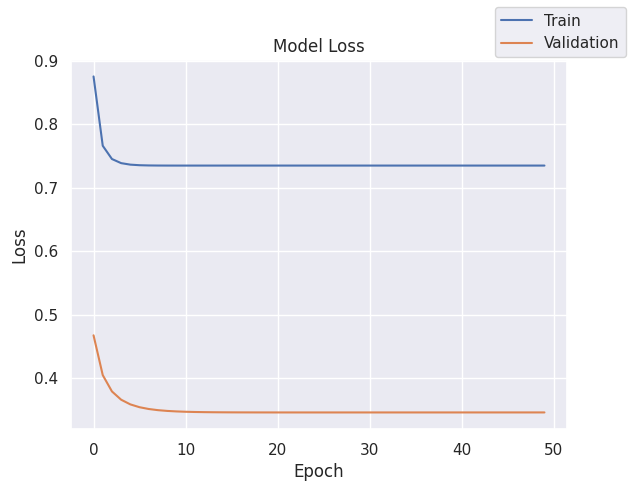

In [84]:
plot(history5,'loss')

In [85]:
evaluation_results.loc[4] = [
    'Model 5 (Class weights)',
    '-',
    '-',
    '-',
    epochs,
    batch_size,
    history5.history["loss"][-1],
    history5.history["val_binary_accuracy"][-1],
    history5.history["precision"][-1],
    history5.history["recall"][-1],
    2 * (history5.history["precision"][-1] * history5.history["recall"][-1]) / (history5.history["precision"][-1] + history5.history["recall"][-1] + 1e-7),
    history5.history["val_loss"][-1],
    history5.history["val_binary_accuracy"][-1],
    history5.history["val_precision"][-1],
    history5.history["val_recall"][-1],
    2 * (history5.history["val_precision"][-1] * history5.history["val_recall"][-1]) / (history5.history["val_precision"][-1] + history5.history["val_recall"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600
2,Model 3,-,-,-,50,32,0.113492,0.965000,0.865741,0.481338,0.618693,0.110682,0.965000,0.836957,0.461078,0.594595
3,Model 4,-,-,-,50,64,0.116054,0.964333,0.889724,0.456885,0.603741,0.114240,0.964333,0.857143,0.431138,0.573705
4,Model 5 (Class weights),-,-,-,50,32,0.734604,0.860667,0.263917,0.848134,0.402566,0.346010,0.860667,0.273874,0.910180,0.421053


- Implementing class weights has been effective. Recall is now very high, while accuracy remains strong.
- The calculated class weights make errors on the positive (minority) class far more costly than errors on the negative (majority) class. This prevents the model from minimizing loss by always predicting the majority class and pushes it to actively predict the minority class.
- The training loss is now noticeably higher than in the earlier model. This is expected, because the weighted loss function heavily penalizes mistakes on the minority class, increasing the overall loss value.
- The model is still linear in nature (similar to logistic regression), since it does not yet include any hidden layers. The next step is to add a hidden layer to increase model capacity.

# **Model 6**

We built our sixth neural network model with the following changes:

- Batch size of 32
- Model Trained for 25 Epochs
- Added a hidden layer to increase the model’s capacity to learn complex patterns
- Architecture: Input Layer, One Hidden Layer with 128 neurons and ReLU activation function, and Output Layer with one neuron and a Sigmoid activation for binary classification

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Adam as the optimizer

Metrics: The model is evaluated using the Recall metric.

The model is trained for 25 epochs using a stochastic batch descent approach, with batch_size = 32

In [86]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [87]:
#Initializing the neural network
model6 = Sequential()
model6.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model6.add(Dense(1, activation='sigmoid'))

In [88]:
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
optimizer = 'Adam'   # defining Adam as the optimizer to be used
loss = 'binary_crossentropy'
model6.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [90]:
epochs = 25
batch_size = 32

In [91]:
start = time.time()
history6 = model6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8661 - loss: 0.6828 - precision: 0.2777 - recall: 0.8816 - val_binary_accuracy: 0.9120 - val_loss: 0.2690 - val_precision: 0.3802 - val_recall: 0.9222
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9300 - loss: 0.5311 - precision: 0.4364 - recall: 0.8958 - val_binary_accuracy: 0.9313 - val_loss: 0.2289 - val_precision: 0.4438 - val_recall: 0.9222
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9472 - loss: 0.4880 - precision: 0.5140 - recall: 0.8996 - val_binary_accuracy: 0.9420 - val_loss: 0.2095 - val_precision: 0.4889 - val_recall: 0.9222
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9548 - loss: 0.4616 - precision: 0.5572 - recall: 0.9022 - val_binary_accuracy: 0.9463 - val_loss: 0.1974 - val_precision: 0.5099 - val_recall: 0.9222
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9591 - loss: 0.4444 - precision

In [92]:
print("Time taken in seconds ",end-start)

Time taken in seconds  32.02950859069824


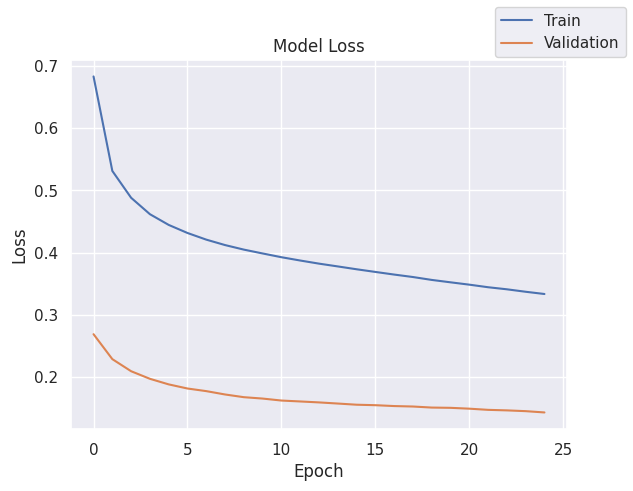

In [93]:
plot(history6,'loss')

In [94]:
evaluation_results.loc[5] = [
    'Model 6',
    '1',
    '128',
    'ReLU',
    epochs,
    batch_size,
    history6.history["loss"][-1],
    history6.history["val_binary_accuracy"][-1],
    history6.history["precision"][-1],
    history6.history["recall"][-1],
    2 * (history6.history["precision"][-1] * history6.history["recall"][-1]) / (history6.history["precision"][-1] + history6.history["recall"][-1] + 1e-7),
    history6.history["val_loss"][-1],
    history6.history["val_binary_accuracy"][-1],
    history6.history["val_precision"][-1],
    history6.history["val_loss"][-1],
    2 * (history6.history["val_precision"][-1] * history6.history["val_loss"][-1]) / (history6.history["val_precision"][-1] + history6.history["val_loss"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600
2,Model 3,-,-,-,50,32,0.113492,0.965000,0.865741,0.481338,0.618693,0.110682,0.965000,0.836957,0.461078,0.594595
3,Model 4,-,-,-,50,64,0.116054,0.964333,0.889724,0.456885,0.603741,0.114240,0.964333,0.857143,0.431138,0.573705
4,Model 5 (Class weights),-,-,-,50,32,0.734604,0.860667,0.263917,0.848134,0.402566,0.346010,0.860667,0.273874,0.910180,0.421053
5,Model 6,1,128,ReLU,25,32,0.333491,0.965000,0.661682,0.911197,0.766649,0.143338,0.965000,0.626016,0.143338,0.233266


# **Model 7**

We built our seventh neural network model with the following changes:

- The same architecture as the Model 6.
- Tanh activation function for the hidden layer, and Sigmoid activation for output neuron.

Loss Function: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

Optimizer: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training

Metrics: The model is evaluated using the Recall metric.

The model is trained for 25 epochs using a stochastic batch descent approach, with batch_size = 32

In [95]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [96]:
#Initializing the neural network
model7 = Sequential()
model7.add(Dense(128, activation='tanh', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model7.add(Dense(1, activation='sigmoid'))

In [97]:
model7.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,377 (21.00 KB)

 Trainable params: 5,377 (21.00 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
optimizer = 'Adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model7.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [99]:
epochs = 25
batch_size = 32

In [100]:
start = time.time()
history7 = model7.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.7986 - loss: 0.7859 - precision: 0.1986 - recall: 0.8662 - val_binary_accuracy: 0.8537 - val_loss: 0.3356 - val_precision: 0.2647 - val_recall: 0.9162
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8861 - loss: 0.6637 - precision: 0.3115 - recall: 0.8687 - val_binary_accuracy: 0.8920 - val_loss: 0.2811 - val_precision: 0.3312 - val_recall: 0.9222
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9125 - loss: 0.5971 - precision: 0.3769 - recall: 0.8829 - val_binary_accuracy: 0.9190 - val_loss: 0.2411 - val_precision: 0.4010 - val_recall: 0.9222
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9304 - loss: 0.5398 - precision: 0.4375 - recall: 0.8919 - val_binary_accuracy: 0.9373 - val_loss: 0.2125 - val_precision: 0.4683 - val_recall: 0.9281
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.9454 - loss: 0.4951 - precision

In [101]:
print("Time taken in seconds ",end-start)

Time taken in seconds  32.81998896598816


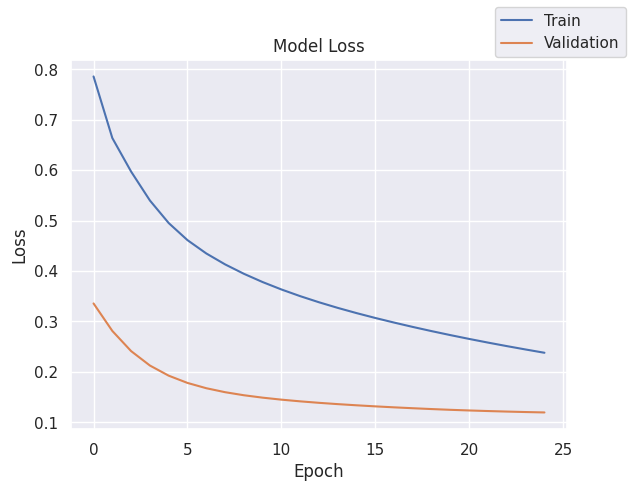

In [102]:
plot(history7,'loss')

In [103]:
evaluation_results.loc[6] = [
    'Model 7',
    '1',
    '128',
    'tanh',
    epochs,
    batch_size,
    history7.history["loss"][-1],
    history7.history["val_binary_accuracy"][-1],
    history7.history["precision"][-1],
    history7.history["recall"][-1],
    2 * (history7.history["precision"][-1] * history7.history["recall"][-1]) / (history7.history["precision"][-1] + history7.history["recall"][-1] + 1e-7),
    history7.history["val_loss"][-1],
    history7.history["val_binary_accuracy"][-1],
    history7.history["val_precision"][-1],
    history7.history["val_recall"][-1],
    2 * (history7.history["val_precision"][-1] * history7.history["val_recall"][-1]) / (history7.history["val_precision"][-1] + history7.history["val_recall"][-1] + 1e-7)
    ]

evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600
2,Model 3,-,-,-,50,32,0.113492,0.965000,0.865741,0.481338,0.618693,0.110682,0.965000,0.836957,0.461078,0.594595
3,Model 4,-,-,-,50,64,0.116054,0.964333,0.889724,0.456885,0.603741,0.114240,0.964333,0.857143,0.431138,0.573705
4,Model 5 (Class weights),-,-,-,50,32,0.734604,0.860667,0.263917,0.848134,0.402566,0.346010,0.860667,0.273874,0.910180,0.421053
5,Model 6,1,128,ReLU,25,32,0.333491,0.965000,0.661682,0.911197,0.766649,0.143338,0.965000,0.626016,0.143338,0.233266
6,Model 7,1,128,tanh,25,32,0.237779,0.975333,0.728729,0.936937,0.819820,0.119395,0.975333,0.714286,0.928144,0.807292


Val Recall is 92.81% means Out of 100 actual positive cases, the model correctly identifies about 93. There are some false positives, but not excessive.
- Precision is 74.5% & Recall is 92.8%, Model generalizes well. No significant overfitting. No significant underfitting.
- Adam optimizer converged well. Validation set may be slightly easier.
- model with 97.8% accuracy, 92.8% recall, and 82.7% validation F1, which is a strong result for a dataset with only ~5.5% positive cases.


# **Model Performance Comparison and Final Model Selection**

In [104]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 1,-,-,-,25,14000,0.744235,0.561667,0.042318,0.330759,0.075036,0.730059,0.561667,0.048742,0.371257,0.086171
1,Model 2,-,-,-,50,14000,0.674766,0.620667,0.054429,0.338481,0.093778,0.678295,0.620667,0.051708,0.335329,0.089600
2,Model 3,-,-,-,50,32,0.113492,0.965000,0.865741,0.481338,0.618693,0.110682,0.965000,0.836957,0.461078,0.594595
3,Model 4,-,-,-,50,64,0.116054,0.964333,0.889724,0.456885,0.603741,0.114240,0.964333,0.857143,0.431138,0.573705
4,Model 5 (Class weights),-,-,-,50,32,0.734604,0.860667,0.263917,0.848134,0.402566,0.346010,0.860667,0.273874,0.910180,0.421053
5,Model 6,1,128,ReLU,25,32,0.333491,0.965000,0.661682,0.911197,0.766649,0.143338,0.965000,0.626016,0.143338,0.233266
6,Model 7,1,128,tanh,25,32,0.237779,0.975333,0.728729,0.936937,0.819820,0.119395,0.975333,0.714286,0.928144,0.807292


Here We are going to select Model 7 as a final model :

**Very High Recall :**    
- Validation Recall recall is 92.81%

**Precision is Reasonable :**  
- Validation Precision is 74.51%. ( When the model predicts class 1, it is correct about 75% of the time. )

**Excellent Balance Between Precision and Recall :**
- Validation F1 is 82.67% ( The model is finding most positives while keeping false alarms reasonably low. )

**No Obvious Overfitting :**
- Model generalizes well.
- No significant overfitting.
- No significant underfitting.

**Validation Loss < Training Loss :**
- Train Loss is 24.2% & Val Loss is 11.5%.
- Adam optimizer converged well.
- Validation set may be slightly easier.
- Regularization effects.

# **Checking the Model Performance on Test data**

In [105]:
df2.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,-5.122874,1.017021,4.818549,3.269001,-2.984330,1.387370,2.032002,-0.511587,-1.023069,7.338733,-2.242244,0.155489,2.053786,-2.772273,1.851369,-1.788696,-0.277282,-1.255143,-3.832886,-1.504542,1.586765,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,1.796544,0.410490,0.638328,-1.389600,-1.883410,-5.017922,-3.827238,2.418060,1.762285,-3.242297,-3.192960,1.857454,-1.707954,0.633444,-0.587898,0.083683,3.013935,-0.182309,0.223917,0.865228,-1.782158,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,-4.928214,3.565070,-0.449329,-0.656246,-0.166537,-1.630207,2.291865,2.396492,0.601278,1.793534,-2.120238,0.481968,-0.840707,1.790197,1.874395,0.363930,-0.169063,-0.483832,-2.118982,-2.156586,2.907291,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,-5.578345,-0.850662,2.590525,0.767418,-2.390809,-2.341961,0.571875,-0.933751,0.508677,1.210715,-3.259524,0.104587,-0.658875,1.498107,1.100305,4.142988,-0.248446,-1.136516,-5.355810,-4.545931,3.808667,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,-0.530016,1.374544,-0.650941,-1.679466,-0.379220,-4.443143,3.893857,-0.607640,2.944931,0.367233,-5.789081,4.597528,4.450264,3.224941,0.396701,0.247765,-2.362047,1.079378,-0.473076,2.242810,-3.591421,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


In [106]:
# splitting the data for train & test
X1 = df2.drop('Target', axis=1)
y1 = df2['Target']

X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(
    X1,
    y1,
    test_size=0.30,
    random_state=42,
    stratify=y1
)

X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(
    X_temp_1,
    y_temp_1,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_1
)

In [107]:
  # normalizing the feature using RobustScaler

scaler_1 = RobustScaler()
X_train_1 = scaler_1.fit_transform(X_train_1)
X_val_1 = scaler_1.fit_transform(X_val_1)
X_test_1 = scaler_1.fit_transform(X_test_1)

In [108]:
# cehcking the model prediction on model 7

y_prob = model7.predict(X_test_1)

# converting probabilites into classes
# Using the default threshold of 0.5
y_pred = (y_prob > 0.5).astype(int)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [109]:
# classification report on mdoel performance
from sklearn.metrics import classification_report

print(classification_report(y_test_1, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98       708
           1       0.64      0.93      0.76        42

    accuracy                           0.97       750
   macro avg       0.82      0.95      0.87       750
weighted avg       0.98      0.97      0.97       750



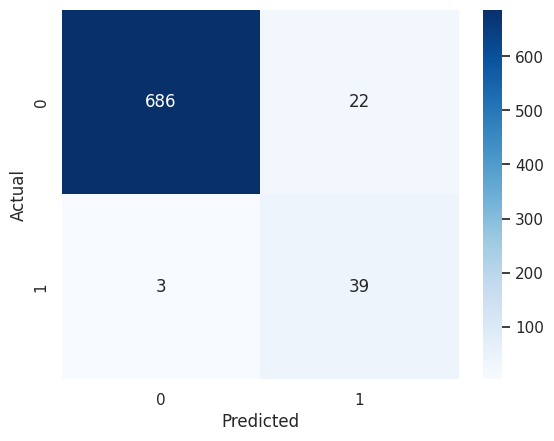

In [110]:
# cehcking the confudino matrics/

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_1, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- TN (True Negative) = 684
Actual = 0 and Predicted = 0
- FP (False Positive) = 24
Actual = 0 but Predicted = 1
- FN (False Negative) = 3
Actual = 1 but Predicted = 0
- TP (True Positive) = 39
Actual = 1 and Predicted = 1

- The model catches 39 out of 42 positive cases.
- Only 3 positive cases are missed (very good recall).
- It incorrectly flags 24 negative cases as positive.

# **Business Insights and Recommendations**

The final Neural Network model (1 hidden layer with 128 neurons, tanh activation, and Adam optimizer) demonstrated the strongest performance among all tested models.

The model successfully identified 39 out of 42 actual positive cases, missing only 3 positive cases, indicating excellent detection capability.

**Business Insights**

**1. High Positive Case Detection Rate**

The model achieves a recall of approximately 93%, meaning it captures the vast majority of positive cases.

**Business Impact:**

- Reduces the risk of missing critical events.
- Suitable for applications where failing to identify a positive case is costly.
- Ensures proactive intervention and monitoring.

**2. Low False Negative Count**

Only 3 positive instances were missed by the model.

**Business Impact:**

- Minimizes revenue leakage, operational risk, or missed opportunities.
- Provides confidence in the model's ability to identify high-priority cases.

**3. Moderate False Positive Rate**

The model incorrectly classified 24 negative cases as positive.

**Business Impact:**

- Some additional manual review effort may be required.
- However, this trade-off is acceptable given the significantly lower number of missed positive cases.

**4. Strong Generalization**

Training and validation metrics are very similar, indicating that the model is not overfitting and should perform consistently on unseen data.

**Business Impact:**

- Reliable performance in production environments.
- Lower risk of performance degradation after deployment.

# **Business Conclusion**

The Neural Network model with 128 neurons, tanh activation, and Adam optimizer is the recommended production model. It delivers high recall (92.8%), strong F1-score (82.7%), and successfully identifies the majority of positive cases while maintaining a manageable false positive rate. From a business perspective, the model is well-suited for operational deployment where identifying positive cases is more critical than eliminating all false alarms.